# Import des librairies

In [2]:
import matplotlib.pyplot as plt
from itertools import islice
from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import clear_output, display
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

from NN import PyTorchMLPDropout, PyTorchMLPDropConnect

c:\Users\François\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Demo on MNIST

## Loading the dataset

Loading Fashion-MNIST: 100%|██████████| 10/10 [00:00<00:00, 110.36it/s]


MNIST (train, test) : 60000, 10000
Fashion-MNIST (train, test) : 60000, 10000
Examples of MNIST and Fashion-MNIST images:


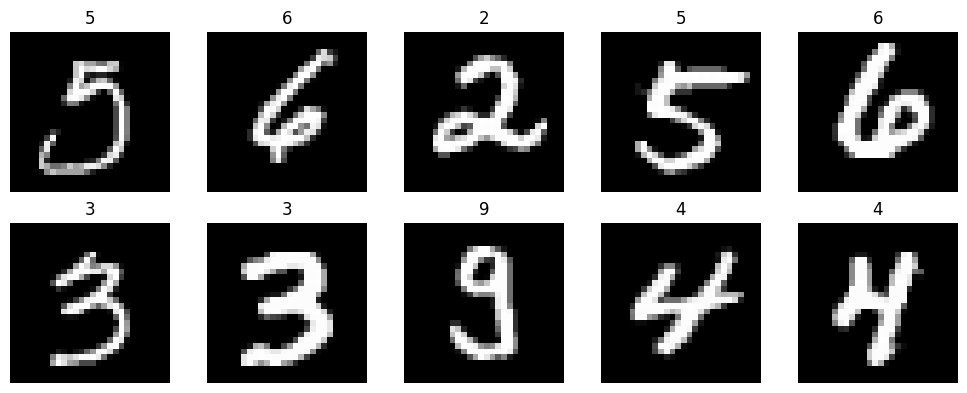

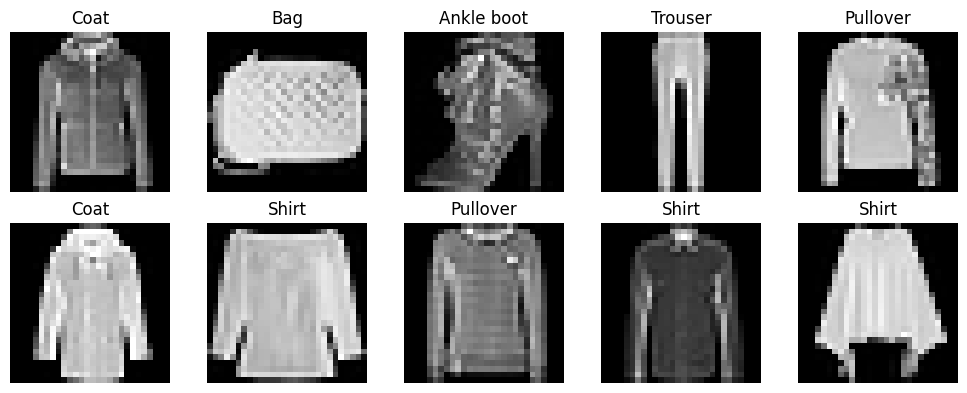

In [6]:
data_root = "./dataset"
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

mnist_train = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root=data_root, train=False, download=True, transform=transform)

fashion_train = datasets.FashionMNIST(root=data_root, train=True, download=True, transform=transform)
fashion_test = datasets.FashionMNIST(root=data_root, train=False, download=True, transform=transform)

mnist_train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

fashion_train_loader = DataLoader(fashion_train, batch_size=batch_size, shuffle=True)
fashion_test_loader = DataLoader(fashion_test, batch_size=batch_size, shuffle=False)

# Loading bar
for _ in tqdm(islice(mnist_train_loader, 10), total=10, desc="Loading MNIST"):
    pass
for _ in tqdm(islice(fashion_train_loader, 10), total=10, desc="Loading Fashion-MNIST"):
    pass

print(f"MNIST (train, test) : {len(mnist_train)}, {len(mnist_test)}\nFashion-MNIST (train, test) : {len(fashion_train)}, {len(fashion_test)}")

print("Examples of MNIST and Fashion-MNIST images:")

# Display 10 random MNIST images with their labels
if "mnist_train" not in globals():
    data_root = "./dataset"
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
    mnist_train = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)

idx = np.random.choice(len(mnist_train), size=10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

for ax, i in zip(axes, idx):
    img, label = mnist_train[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")

plt.tight_layout()
plt.show()

# Display 10 random Fashion-MNIST images with their labels
if "fashion_train" not in globals():
    data_root = "./dataset"
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
    fashion_train = datasets.FashionMNIST(root=data_root, train=True, download=True, transform=transform)

fashion_classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
 ]

idx = np.random.choice(len(fashion_train), size=10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

for ax, i in zip(axes, idx):
    img, label = fashion_train[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(fashion_classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Training our models

### Supervised Learning : Multi-Layer Perceptron

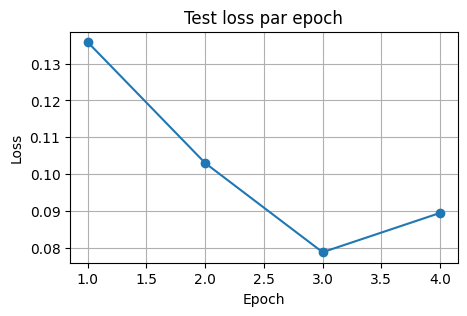

MLP_MNIST(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=32, bias=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [7]:
# Entraînement d'un MLP sur GPU (si dispo)
from IPython.display import clear_output, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class MLP_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        return self.net(x)

mlp_mnist = MLP_MNIST().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_mnist.parameters(), lr=1e-3)

epochs = 4
test_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    mlp_mnist.train()
    running_loss = 0.0
    for x, y in tqdm(mnist_train_loader, desc=f"Epoch {epoch}"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = mlp_mnist(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(mnist_train_loader.dataset)

    mlp_mnist.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    with torch.no_grad():
        for x, y in mnist_test_loader:
            x, y = x.to(device), y.to(device)
            logits = mlp_mnist(x)
            loss = criterion(logits, y)
            test_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    test_loss = test_loss / len(mnist_test_loader.dataset)
    test_losses.append(test_loss)
    acc = correct / total
    print(f"Epoch {epoch} - loss: {train_loss:.4f} - val_loss: {test_loss:.4f} - acc: {acc:.4f}")

    # Actualisation du même graphe (taille fixe)
    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(test_losses) + 1), test_losses, marker="o")
    ax.set_title("Test loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(mlp_mnist)

### Supervised Learning : Convolutional Neural Network

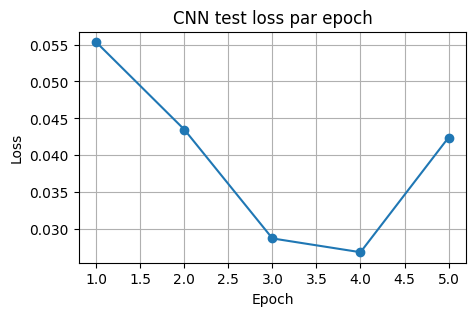

CNN_MNIST(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=32, bias=True)
    (6): ReLU()
    (7): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [8]:
# Entraînement d'un CNN sur GPU (si dispo)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class CNN_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 32), nn.ReLU(),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn_mnist = CNN_MNIST().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_mnist.parameters(), lr=1e-3)

epochs = 5
test_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    cnn_mnist.train()
    running_loss = 0.0
    for x, y in tqdm(mnist_train_loader, desc=f"CNN Epoch {epoch}"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = cnn_mnist(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(mnist_train_loader.dataset)

    cnn_mnist.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    with torch.no_grad():
        for x, y in mnist_test_loader:
            x, y = x.to(device), y.to(device)
            logits = cnn_mnist(x)
            loss = criterion(logits, y)
            test_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    test_loss = test_loss / len(mnist_test_loader.dataset)
    test_losses.append(test_loss)
    acc = correct / total
    print(f"CNN Epoch {epoch} - loss: {train_loss:.4f} - val_loss: {test_loss:.4f} - acc: {acc:.4f}")

    # Actualisation du même graphe (taille fixe)
    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(test_losses) + 1), test_losses, marker="o")
    ax.set_title("CNN test loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(cnn_mnist)

### Unsupervised Learning : MLP Auto-Encoder

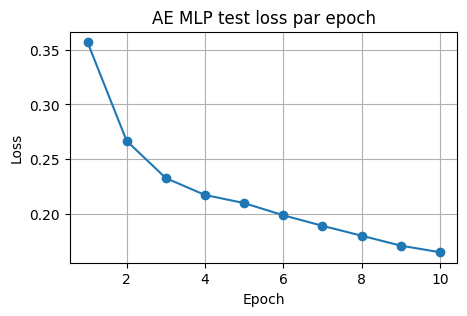

AE_MLP_MNIST(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=512, bias=True)
    (7): ReLU()
    (8): Linear(in_features=512, out_features=784, bias=True)
  )
)


In [9]:
# Entraînement d'un Auto-Encodeur MLP (miroir) sur GPU (si dispo)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class AE_MLP_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 28 * 28)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

ae_mlp_mnist = AE_MLP_MNIST().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_mlp_mnist.parameters(), lr=1e-3)

epochs = 10
test_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    ae_mlp_mnist.train()
    running_loss = 0.0
    for x, _ in tqdm(mnist_train_loader, desc=f"AE Epoch {epoch}"):
        x = x.to(device)
        x_flat = x.view(x.size(0), -1)
        optimizer.zero_grad()
        recon = ae_mlp_mnist(x_flat)
        loss = criterion(recon, x_flat)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(mnist_train_loader.dataset)

    ae_mlp_mnist.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x, _ in mnist_test_loader:
            x = x.to(device)
            x_flat = x.view(x.size(0), -1)
            recon = ae_mlp_mnist(x_flat)
            loss = criterion(recon, x_flat)
            test_loss += loss.item() * x.size(0)
    test_loss = test_loss / len(mnist_test_loader.dataset)
    test_losses.append(test_loss)
    print(f"AE Epoch {epoch} - loss: {train_loss:.4f} - val_loss: {test_loss:.4f}")

    # Actualisation du même graphe (taille fixe)
    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(test_losses) + 1), test_losses, marker="o")
    ax.set_title("AE MLP test loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(ae_mlp_mnist)

### Unsupervised Learning : CNN Auto-Encoder

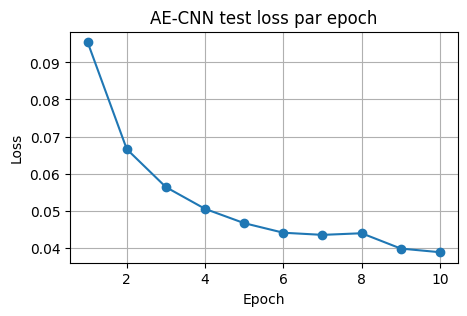

AE_CNN_MNIST(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bottleneck): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=32, bias=True)
  )
  (unbottleneck): Sequential(
    (0): Linear(in_features=32, out_features=6272, bias=True)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [10]:
# Entraînement d'un Auto-Encodeur CNN (miroir) sur GPU (si dispo)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class AE_CNN_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.bottleneck = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 32)
        )
        self.unbottleneck = nn.Sequential(
            nn.Linear(32, 128 * 7 * 7),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2), nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        x = self.encoder(x)
        z = self.bottleneck(x)
        x = self.unbottleneck(z).view(-1, 128, 7, 7)
        x = self.decoder(x)
        return x

ae_cnn_mnist = AE_CNN_MNIST().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_cnn_mnist.parameters(), lr=1e-3)

epochs = 10
test_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    ae_cnn_mnist.train()
    running_loss = 0.0
    for x, _ in tqdm(mnist_train_loader, desc=f"AE-CNN Epoch {epoch}"):
        x = x.to(device)
        optimizer.zero_grad()
        recon = ae_cnn_mnist(x)
        loss = criterion(recon, x)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(mnist_train_loader.dataset)

    ae_cnn_mnist.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x, _ in mnist_test_loader:
            x = x.to(device)
            recon = ae_cnn_mnist(x)
            loss = criterion(recon, x)
            test_loss += loss.item() * x.size(0)
    test_loss = test_loss / len(mnist_test_loader.dataset)
    test_losses.append(test_loss)
    print(f"AE-CNN Epoch {epoch} - loss: {train_loss:.4f} - val_loss: {test_loss:.4f}")

    # Actualisation du même graphe (taille fixe)
    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(test_losses) + 1), test_losses, marker="o")
    ax.set_title("AE-CNN test loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(ae_cnn_mnist)

### Model performance comparaison

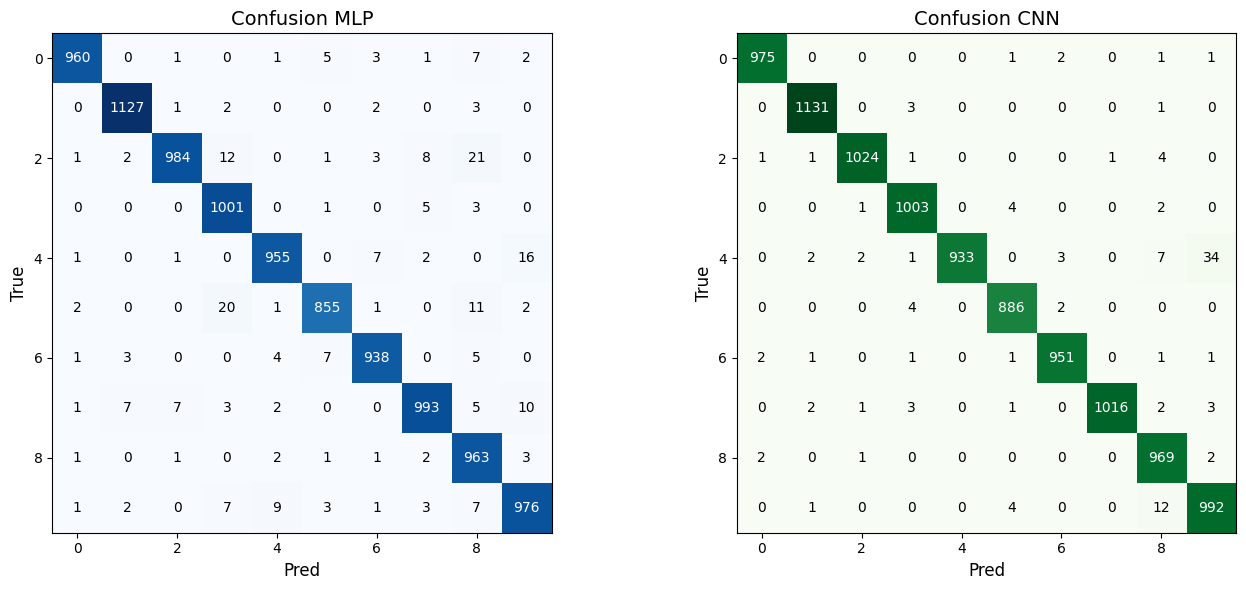

,model,accuracy,precision_macro,recall_macro,f1_macro
0,MLP,0.9752,0.975345,0.974922,0.974988
1,CNN,0.9880,0.988082,0.987910,0.987898


In [11]:
# Comparaison MLP vs CNN sur le test set
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_mnist.eval()
cnn_mnist.eval()

y_true = []
y_pred_mlp = []
y_pred_cnn = []

with torch.no_grad():
    for x, y in mnist_test_loader:
        x = x.to(device)
        logits_mlp = mlp_mnist(x)
        logits_cnn = cnn_mnist(x)
        y_true.extend(y.numpy().tolist())
        y_pred_mlp.extend(logits_mlp.argmax(dim=1).cpu().numpy().tolist())
        y_pred_cnn.extend(logits_cnn.argmax(dim=1).cpu().numpy().tolist())

cm_mlp = confusion_matrix(y_true, y_pred_mlp)
cm_cnn = confusion_matrix(y_true, y_pred_cnn)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cm_mlp, cmap="Blues")
axes[0].set_title("Confusion MLP", fontsize=14)
axes[0].set_xlabel("Pred", fontsize=12)
axes[0].set_ylabel("True", fontsize=12)
axes[1].imshow(cm_cnn, cmap="Greens")
axes[1].set_title("Confusion CNN", fontsize=14)
axes[1].set_xlabel("Pred", fontsize=12)
axes[1].set_ylabel("True", fontsize=12)

# Afficher les valeurs dans chaque case
for i in range(cm_mlp.shape[0]):
    for j in range(cm_mlp.shape[1]):
        axes[0].text(j, i, cm_mlp[i, j], ha="center", va="center", fontsize=10,
                     color="white" if cm_mlp[i, j] > cm_mlp.max() / 2 else "black")
for i in range(cm_cnn.shape[0]):
    for j in range(cm_cnn.shape[1]):
        axes[1].text(j, i, cm_cnn[i, j], ha="center", va="center", fontsize=10,
                     color="white" if cm_cnn[i, j] > cm_cnn.max() / 2 else "black")

plt.tight_layout()
plt.show()

metrics = pd.DataFrame([
    {
        "model": "MLP",
        "accuracy": accuracy_score(y_true, y_pred_mlp),
        "precision_macro": precision_score(y_true, y_pred_mlp, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred_mlp, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred_mlp, average="macro", zero_division=0),
    },
    {
        "model": "CNN",
        "accuracy": accuracy_score(y_true, y_pred_cnn),
        "precision_macro": precision_score(y_true, y_pred_cnn, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred_cnn, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred_cnn, average="macro", zero_division=0),
    }
])

metrics

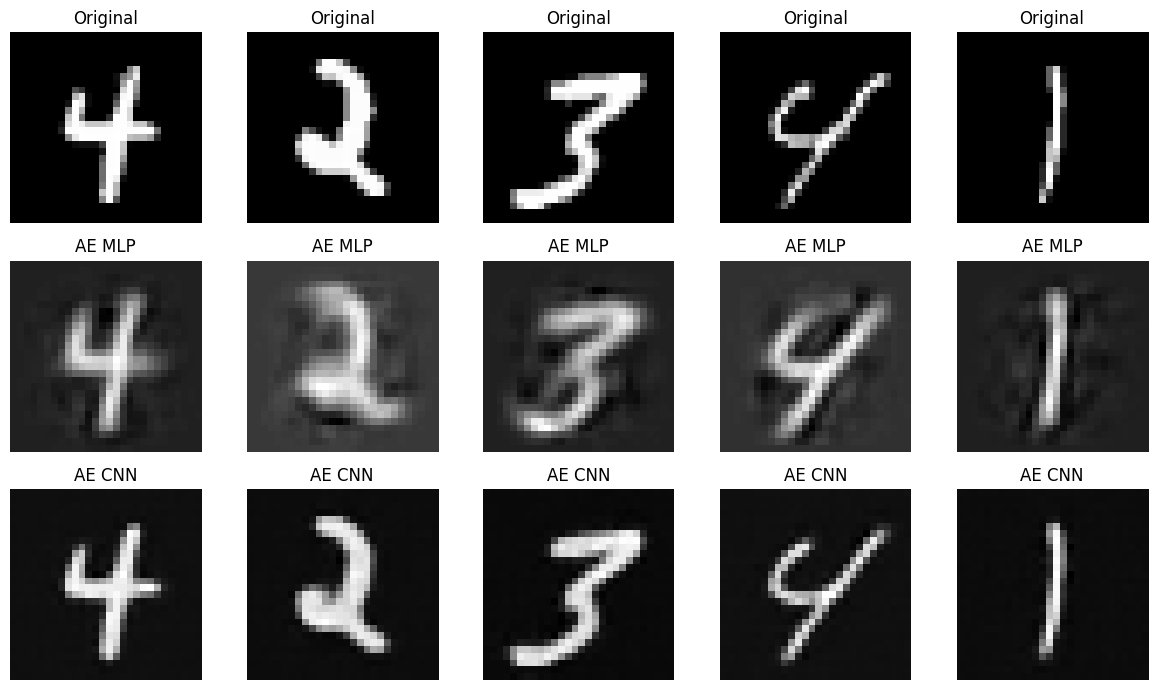

In [12]:
# Comparer les reconstructions des auto-encodeurs (5 images test)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ae_mlp_mnist.eval()
ae_cnn_mnist.eval()

idx = np.random.choice(len(mnist_test), size=5, replace=False)
images = torch.stack([mnist_test[i][0] for i in idx]).to(device)

with torch.no_grad():
    recon_mlp = ae_mlp_mnist(images.view(images.size(0), -1)).view(-1, 1, 28, 28)
    recon_cnn = ae_cnn_mnist(images)

images = images.cpu()
recon_mlp = recon_mlp.cpu()
recon_cnn = recon_cnn.cpu()

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for i in range(5):
    axes[0, i].imshow(images[i].squeeze(), cmap="gray")
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")
    axes[1, i].imshow(recon_mlp[i].squeeze(), cmap="gray")
    axes[1, i].set_title("AE MLP")
    axes[1, i].axis("off")
    axes[2, i].imshow(recon_cnn[i].squeeze(), cmap="gray")
    axes[2, i].set_title("AE CNN")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

## Uncertainty Quantification

### Save 32 neurons datasets

In [13]:
# Sauvegarde des datasets 32D pour tout MNIST (train + test)
import os
from torch.utils.data import ConcatDataset

device = next(mlp_mnist.parameters()).device

mnist_full = ConcatDataset([mnist_train, mnist_test])
mnist_full_loader = DataLoader(mnist_full, batch_size=batch_size, shuffle=False)

@torch.no_grad()
def extract_mlp_features(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        f = model.net[:-1](x)
        feats.append(f.cpu())
        labels.append(y.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)

@torch.no_grad()
def extract_cnn_features(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        f = model.classifier[:-1](model.features(x))
        feats.append(f.cpu())
        labels.append(y.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)

@torch.no_grad()
def extract_ae_mlp_features(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        x_flat = x.view(x.size(0), -1)
        f = model.encoder(x_flat)
        feats.append(f.cpu())
        labels.append(y.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)

@torch.no_grad()
def extract_ae_cnn_features(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        f = model.bottleneck(model.encoder(x))
        feats.append(f.cpu())
        labels.append(y.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)

X_mlp_full, y_full = extract_mlp_features(mlp_mnist, mnist_full_loader)
X_cnn_full, y_cnn_full = extract_cnn_features(cnn_mnist, mnist_full_loader)
X_ae_mlp_full, y_ae_mlp_full = extract_ae_mlp_features(ae_mlp_mnist, mnist_full_loader)
X_ae_cnn_full, y_ae_cnn_full = extract_ae_cnn_features(ae_cnn_mnist, mnist_full_loader)

assert torch.equal(y_full, y_cnn_full)
assert torch.equal(y_full, y_ae_mlp_full)
assert torch.equal(y_full, y_ae_cnn_full)

mnist_mlp_32 = TensorDataset(X_mlp_full, y_full)
mnist_cnn_32 = TensorDataset(X_cnn_full, y_full)
mnist_ae_mlp_32 = TensorDataset(X_ae_mlp_full, y_full)
mnist_ae_cnn_32 = TensorDataset(X_ae_cnn_full, y_full)

out_dir = os.path.join(data_root, "representations_32")
os.makedirs(out_dir, exist_ok=True)

torch.save(mnist_mlp_32, os.path.join(out_dir, "mnist_mlp_32.pt"))
torch.save(mnist_cnn_32, os.path.join(out_dir, "mnist_cnn_32.pt"))
torch.save(mnist_ae_mlp_32, os.path.join(out_dir, "mnist_ae_mlp_32.pt"))
torch.save(mnist_ae_cnn_32, os.path.join(out_dir, "mnist_ae_cnn_32.pt"))

print("Sauvegarde OK:", out_dir)

Sauvegarde OK: ./dataset\representations_32


In [14]:
# Extraire et sauvegarder 1000 Fashion-MNIST (représentations 32D)
from torch.utils.data import Subset

rng = np.random.default_rng(0)
fashion_idx_1k = rng.choice(len(fashion_test), size=1000, replace=False)
fashion_subset_1k = Subset(fashion_test, fashion_idx_1k)
fashion_loader_1k = DataLoader(fashion_subset_1k, batch_size=256, shuffle=False)

X_mlp_fashion_1k, y_fashion_1k = extract_mlp_features(mlp_mnist, fashion_loader_1k)
X_cnn_fashion_1k, y_cnn_fashion_1k = extract_cnn_features(cnn_mnist, fashion_loader_1k)
X_ae_mlp_fashion_1k, y_ae_mlp_fashion_1k = extract_ae_mlp_features(ae_mlp_mnist, fashion_loader_1k)
X_ae_cnn_fashion_1k, y_ae_cnn_fashion_1k = extract_ae_cnn_features(ae_cnn_mnist, fashion_loader_1k)

assert torch.equal(y_fashion_1k, y_cnn_fashion_1k)
assert torch.equal(y_fashion_1k, y_ae_mlp_fashion_1k)
assert torch.equal(y_fashion_1k, y_ae_cnn_fashion_1k)

fashion_mlp_32_1k = TensorDataset(X_mlp_fashion_1k, y_fashion_1k)
fashion_cnn_32_1k = TensorDataset(X_cnn_fashion_1k, y_fashion_1k)
fashion_ae_mlp_32_1k = TensorDataset(X_ae_mlp_fashion_1k, y_fashion_1k)
fashion_ae_cnn_32_1k = TensorDataset(X_ae_cnn_fashion_1k, y_fashion_1k)

out_dir = os.path.join(data_root, "representations_32")
os.makedirs(out_dir, exist_ok=True)

torch.save(fashion_mlp_32_1k, os.path.join(out_dir, "fashion_mlp_32_1k.pt"))
torch.save(fashion_cnn_32_1k, os.path.join(out_dir, "fashion_cnn_32_1k.pt"))
torch.save(fashion_ae_mlp_32_1k, os.path.join(out_dir, "fashion_ae_mlp_32_1k.pt"))
torch.save(fashion_ae_cnn_32_1k, os.path.join(out_dir, "fashion_ae_cnn_32_1k.pt"))

print("Sauvegarde OK (Fashion 1k):", out_dir)

Sauvegarde OK (Fashion 1k): ./dataset\representations_32


### Random forest

C:\Users\François\AppData\Local\Temp\ipykernel_36700\899815588.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mnist_mlp_32 = torch.load(os.path.join(rep_dir, "mnist_mlp

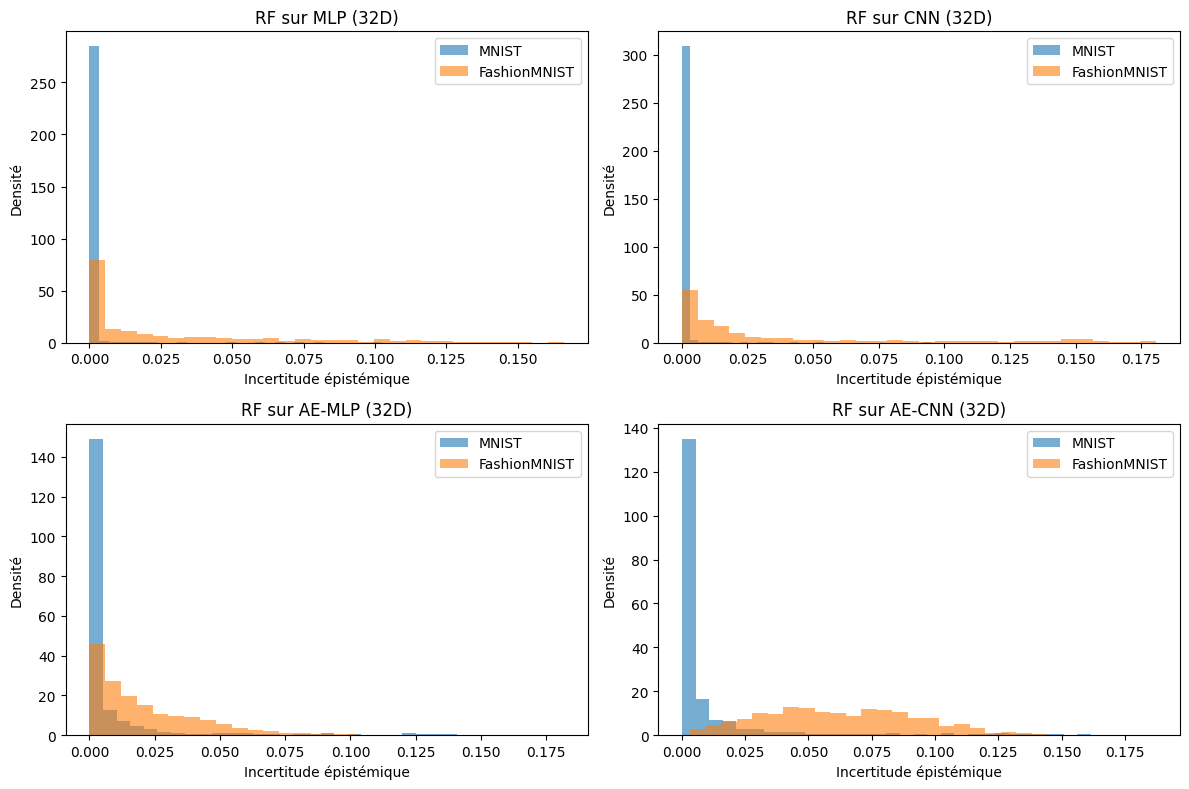

In [ ]:
# Random Forest en chargeant les datasets 32D depuis le disque
import os
import torch
import numpy as np
from sklearn.ensemble import RandomForestClassifier

rep_dir = os.path.join(data_root, "representations_32")
mnist_mlp_32 = torch.load(os.path.join(rep_dir, "mnist_mlp_32.pt"))
mnist_cnn_32 = torch.load(os.path.join(rep_dir, "mnist_cnn_32.pt"))
mnist_ae_mlp_32 = torch.load(os.path.join(rep_dir, "mnist_ae_mlp_32.pt"))
mnist_ae_cnn_32 = torch.load(os.path.join(rep_dir, "mnist_ae_cnn_32.pt"))
fashion_mlp_32_1k = torch.load(os.path.join(rep_dir, "fashion_mlp_32_1k.pt"))
fashion_cnn_32_1k = torch.load(os.path.join(rep_dir, "fashion_cnn_32_1k.pt"))
fashion_ae_mlp_32_1k = torch.load(os.path.join(rep_dir, "fashion_ae_mlp_32_1k.pt"))
fashion_ae_cnn_32_1k = torch.load(os.path.join(rep_dir, "fashion_ae_cnn_32_1k.pt"))

# Données d'entraînement (MNIST complet en 32D)
X_mlp_train = mnist_mlp_32.tensors[0].numpy()
X_cnn_train = mnist_cnn_32.tensors[0].numpy()
X_ae_mlp_train = mnist_ae_mlp_32.tensors[0].numpy()
X_ae_cnn_train = mnist_ae_cnn_32.tensors[0].numpy()
y_train = mnist_mlp_32.tensors[1].numpy()

# MNIST 1k (échantillonnage depuis les représentations 32D sauvegardées)
rng = np.random.default_rng(1)
mnist_idx_1k = rng.choice(len(y_train), size=1000, replace=False)
X_mlp_mnist_1k_np = mnist_mlp_32.tensors[0][mnist_idx_1k].numpy()
X_cnn_mnist_1k_np = mnist_cnn_32.tensors[0][mnist_idx_1k].numpy()
X_ae_mlp_mnist_1k_np = mnist_ae_mlp_32.tensors[0][mnist_idx_1k].numpy()
X_ae_cnn_mnist_1k_np = mnist_ae_cnn_32.tensors[0][mnist_idx_1k].numpy()

# Fashion 1k (déjà sauvegardé en 32D)
X_mlp_fashion_1k_np = fashion_mlp_32_1k.tensors[0].numpy()
X_cnn_fashion_1k_np = fashion_cnn_32_1k.tensors[0].numpy()
X_ae_mlp_fashion_1k_np = fashion_ae_mlp_32_1k.tensors[0].numpy()
X_ae_cnn_fashion_1k_np = fashion_ae_cnn_32_1k.tensors[0].numpy()

def randomForest(X, y, X_test, nb_estimators=200):
    model = RandomForestClassifier(n_estimators=nb_estimators, min_samples_leaf=5)

    model.fit(X, y)
    preds = np.array(model.predict_proba(X_test))

    # TREE
    unc_tree = []
    p_pred = []
    for tree in model.estimators_:
        pred_t = tree.predict_proba(X_test)
        p_pred.append(pred_t)
        unc_tree.append(-np.sum(pred_t * np.log2(pred_t + 1e-10), axis=1))

    p_pred = np.array(p_pred)
    ep = np.var(p_pred[:,:,0], axis=0)
    return ep, p_pred, preds


ep_mlp_mnist, _, _ = randomForest(X_mlp_train, y_train, X_mlp_mnist_1k_np)
ep_mlp_fashion, _, _ = randomForest(X_mlp_train, y_train, X_mlp_fashion_1k_np)

ep_cnn_mnist, _, _ = randomForest(X_cnn_train, y_train, X_cnn_mnist_1k_np)
ep_cnn_fashion, _, _ = randomForest(X_cnn_train, y_train, X_cnn_fashion_1k_np)

ep_ae_mlp_mnist, _, _ = randomForest(X_ae_mlp_train, y_train, X_ae_mlp_mnist_1k_np)
ep_ae_mlp_fashion, _, _ = randomForest(X_ae_mlp_train, y_train, X_ae_mlp_fashion_1k_np)

ep_ae_cnn_mnist, _, _ = randomForest(X_ae_cnn_train, y_train, X_ae_cnn_mnist_1k_np)
ep_ae_cnn_fashion, _, _ = randomForest(X_ae_cnn_train, y_train, X_ae_cnn_fashion_1k_np)

# Graphes de densité (MNIST vs Fashion 1k)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], ep_mlp_mnist, ep_mlp_fashion, "RF sur MLP (32D)"),
    (axes[0, 1], ep_cnn_mnist, ep_cnn_fashion, "RF sur CNN (32D)"),
    (axes[1, 0], ep_ae_mlp_mnist, ep_ae_mlp_fashion, "RF sur AE-MLP (32D)"),
    (axes[1, 1], ep_ae_cnn_mnist, ep_ae_cnn_fashion, "RF sur AE-CNN (32D)")
]

for ax, ep_mnist, ep_fashion, title in plots:
    ax.hist(ep_mnist, bins=30, density=True, alpha=0.6, label="MNIST")
    ax.hist(ep_fashion, bins=30, density=True, alpha=0.6, label="FashionMNIST")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()

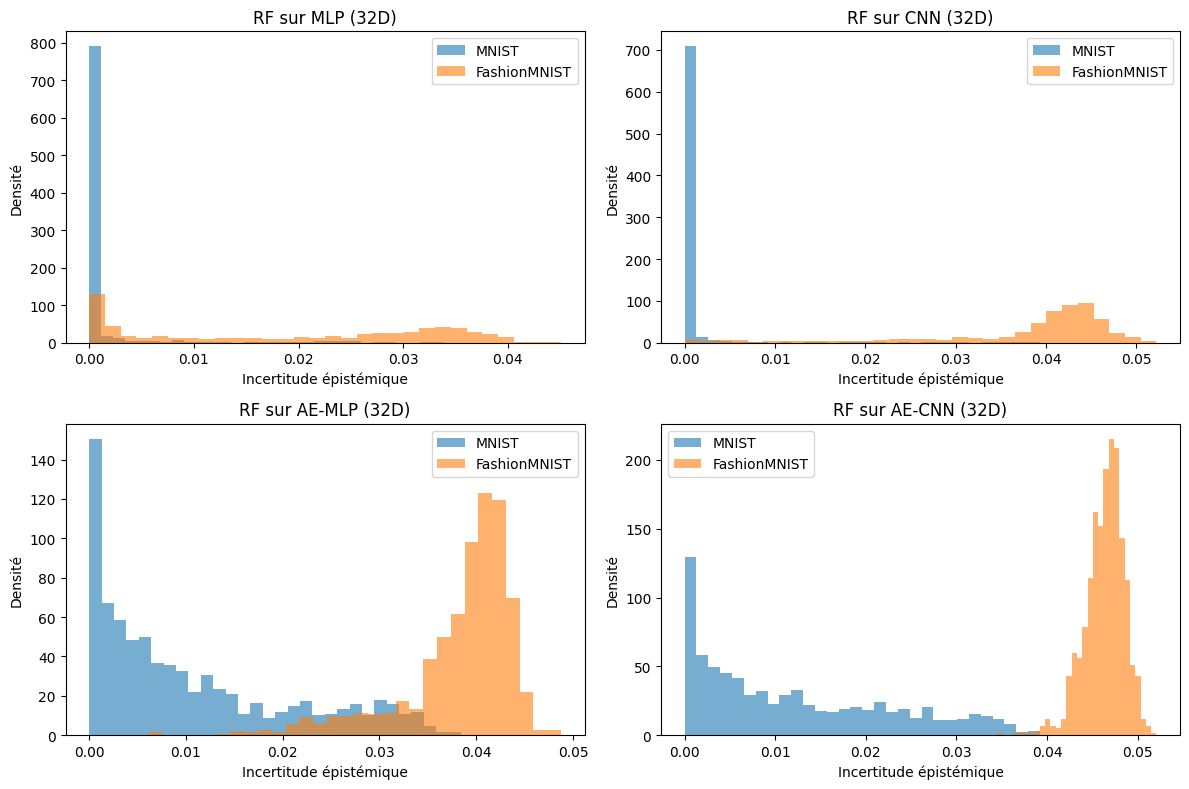

ModuleNotFoundError: No module named 'lib.utils'

In [15]:
# Random Forest sur représentations 32D + incertitude épistémique (MNIST vs Fashion 1k)
from sklearn.ensemble import RandomForestClassifier
from torch.utils.data import Subset

rng = np.random.default_rng(1)
mnist_idx_1k = rng.choice(len(mnist_test), size=1000, replace=False)
mnist_subset_1k = Subset(mnist_test, mnist_idx_1k)
mnist_loader_1k = DataLoader(mnist_subset_1k, batch_size=256, shuffle=False)

# Extraire représentations 32D pour MNIST 1k et Fashion 1k
X_mlp_mnist_1k, y_mnist_1k = extract_mlp_features(mlp_mnist, mnist_loader_1k)
X_cnn_mnist_1k, y_cnn_mnist_1k = extract_cnn_features(cnn_mnist, mnist_loader_1k)
X_ae_mlp_mnist_1k, y_ae_mlp_mnist_1k = extract_ae_mlp_features(ae_mlp_mnist, mnist_loader_1k)
X_ae_cnn_mnist_1k, y_ae_cnn_mnist_1k = extract_ae_cnn_features(ae_cnn_mnist, mnist_loader_1k)

assert torch.equal(y_mnist_1k, y_cnn_mnist_1k)
assert torch.equal(y_mnist_1k, y_ae_mlp_mnist_1k)
assert torch.equal(y_mnist_1k, y_ae_cnn_mnist_1k)

# Conversion en numpy pour sklearn
X_mlp_train = X_mlp_full.numpy()
X_cnn_train = X_cnn_full.numpy()
X_ae_mlp_train = X_ae_mlp_full.numpy()
X_ae_cnn_train = X_ae_cnn_full.numpy()
y_train = y_full.numpy()

X_mlp_mnist_1k_np = X_mlp_mnist_1k.numpy()
X_cnn_mnist_1k_np = X_cnn_mnist_1k.numpy()
X_ae_mlp_mnist_1k_np = X_ae_mlp_mnist_1k.numpy()
X_ae_cnn_mnist_1k_np = X_ae_cnn_mnist_1k.numpy()

X_mlp_fashion_1k_np = X_mlp_fashion_1k.numpy()
X_cnn_fashion_1k_np = X_cnn_fashion_1k.numpy()
X_ae_mlp_fashion_1k_np = X_ae_mlp_fashion_1k.numpy()
X_ae_cnn_fashion_1k_np = X_ae_cnn_fashion_1k.numpy()

# Entraîner 4 Random Forest (plus d'arbres)
rf_mlp = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=0)
rf_cnn = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=0)
rf_ae_mlp = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=0)
rf_ae_cnn = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=0)

rf_mlp.fit(X_mlp_train, y_train)
rf_cnn.fit(X_cnn_train, y_train)
rf_ae_mlp.fit(X_ae_mlp_train, y_train)
rf_ae_cnn.fit(X_ae_cnn_train, y_train)

# Incertitude épistémique via variance inter‑arbres (moyenne sur classes)
def rf_epistemic(rf, X_test):
    p_pred = np.array([tree.predict_proba(X_test) for tree in rf.estimators_])
    ep = np.var(p_pred, axis=0).mean(axis=1)
    return ep

ep_mlp_mnist = rf_epistemic(rf_mlp, X_mlp_mnist_1k_np)
ep_mlp_fashion = rf_epistemic(rf_mlp, X_mlp_fashion_1k_np)

ep_cnn_mnist = rf_epistemic(rf_cnn, X_cnn_mnist_1k_np)
ep_cnn_fashion = rf_epistemic(rf_cnn, X_cnn_fashion_1k_np)

ep_ae_mlp_mnist = rf_epistemic(rf_ae_mlp, X_ae_mlp_mnist_1k_np)
ep_ae_mlp_fashion = rf_epistemic(rf_ae_mlp, X_ae_mlp_fashion_1k_np)

ep_ae_cnn_mnist = rf_epistemic(rf_ae_cnn, X_ae_cnn_mnist_1k_np)
ep_ae_cnn_fashion = rf_epistemic(rf_ae_cnn, X_ae_cnn_fashion_1k_np)

# Graphes de densité (MNIST vs Fashion 1k)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], ep_mlp_mnist, ep_mlp_fashion, "RF sur MLP (32D)"),
    (axes[0, 1], ep_cnn_mnist, ep_cnn_fashion, "RF sur CNN (32D)"),
    (axes[1, 0], ep_ae_mlp_mnist, ep_ae_mlp_fashion, "RF sur AE-MLP (32D)"),
    (axes[1, 1], ep_ae_cnn_mnist, ep_ae_cnn_fashion, "RF sur AE-CNN (32D)")
]

for ax, ep_mnist, ep_fashion, title in plots:
    ax.hist(ep_mnist, bins=30, density=True, alpha=0.6, label="MNIST")
    ax.hist(ep_fashion, bins=30, density=True, alpha=0.6, label="FashionMNIST")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()

### EKNN

In [19]:
# Random Forest en chargeant les datasets 32D depuis le disque
import os
import torch
import numpy as np
from deep_eknn import EKNN

rep_dir = os.path.join(data_root, "representations_32")
mnist_mlp_32 = torch.load(os.path.join(rep_dir, "mnist_mlp_32.pt"))
mnist_cnn_32 = torch.load(os.path.join(rep_dir, "mnist_cnn_32.pt"))
mnist_ae_mlp_32 = torch.load(os.path.join(rep_dir, "mnist_ae_mlp_32.pt"))
mnist_ae_cnn_32 = torch.load(os.path.join(rep_dir, "mnist_ae_cnn_32.pt"))
fashion_mlp_32_1k = torch.load(os.path.join(rep_dir, "fashion_mlp_32_1k.pt"))
fashion_cnn_32_1k = torch.load(os.path.join(rep_dir, "fashion_cnn_32_1k.pt"))
fashion_ae_mlp_32_1k = torch.load(os.path.join(rep_dir, "fashion_ae_mlp_32_1k.pt"))
fashion_ae_cnn_32_1k = torch.load(os.path.join(rep_dir, "fashion_ae_cnn_32_1k.pt"))

# Données d'entraînement (MNIST complet en 32D)
X_mlp_train = mnist_mlp_32.tensors[0].numpy()
X_cnn_train = mnist_cnn_32.tensors[0].numpy()
X_ae_mlp_train = mnist_ae_mlp_32.tensors[0].numpy()
X_ae_cnn_train = mnist_ae_cnn_32.tensors[0].numpy()
y_train = mnist_mlp_32.tensors[1].numpy()

# MNIST 1k (échantillonnage depuis les représentations 32D sauvegardées)
rng = np.random.default_rng(1)
mnist_idx_1k = rng.choice(len(y_train), size=1000, replace=False)
X_mlp_mnist_1k_np = mnist_mlp_32.tensors[0][mnist_idx_1k].numpy()
X_cnn_mnist_1k_np = mnist_cnn_32.tensors[0][mnist_idx_1k].numpy()
X_ae_mlp_mnist_1k_np = mnist_ae_mlp_32.tensors[0][mnist_idx_1k].numpy()
X_ae_cnn_mnist_1k_np = mnist_ae_cnn_32.tensors[0][mnist_idx_1k].numpy()

# Fashion 1k (déjà sauvegardé en 32D)
X_mlp_fashion_1k_np = fashion_mlp_32_1k.tensors[0].numpy()
X_cnn_fashion_1k_np = fashion_cnn_32_1k.tensors[0].numpy()
X_ae_mlp_fashion_1k_np = fashion_ae_mlp_32_1k.tensors[0].numpy()
X_ae_cnn_fashion_1k_np = fashion_ae_cnn_32_1k.tensors[0].numpy()

def EvKNN(X, y, X_test):
    model = EKNN(2, 12)

    model.fit(X, y)
    preds = np.array(model.predict_proba(X_test))

    _, ep = model.get_uncertainties(X_test)
    
    p_pred_0 = []
    for i in range(200):
        sample = np.random.normal(preds[:,0], np.sqrt(ep))
        sample = np.clip(sample, 0, 1)
        p_pred_0.append(sample)
    p_pred_0 = np.array(p_pred_0)
    p_pred = np.array([p_pred_0, 1-p_pred_0]).transpose(1, 2, 0)

    return ep, p_pred, preds


ep_mlp_mnist, _, _ = EvKNN(X_mlp_train, y_train, X_mlp_mnist_1k_np)
ep_mlp_fashion, _, _ = EvKNN(X_mlp_train, y_train, X_mlp_fashion_1k_np)

ep_cnn_mnist, _, _ = EvKNN(X_cnn_train, y_train, X_cnn_mnist_1k_np)
ep_cnn_fashion, _, _ = EvKNN(X_cnn_train, y_train, X_cnn_fashion_1k_np)

ep_ae_mlp_mnist, _, _ = EvKNN(X_ae_mlp_train, y_train, X_ae_mlp_mnist_1k_np)
ep_ae_mlp_fashion, _, _ = EvKNN(X_ae_mlp_train, y_train, X_ae_mlp_fashion_1k_np)

ep_ae_cnn_mnist, _, _ = EvKNN(X_ae_cnn_train, y_train, X_ae_cnn_mnist_1k_np)
ep_ae_cnn_fashion, _, _ = EvKNN(X_ae_cnn_train, y_train, X_ae_cnn_fashion_1k_np)

# Graphes de densité (MNIST vs Fashion 1k)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], ep_mlp_mnist, ep_mlp_fashion, "RF sur MLP (32D)"),
    (axes[0, 1], ep_cnn_mnist, ep_cnn_fashion, "RF sur CNN (32D)"),
    (axes[1, 0], ep_ae_mlp_mnist, ep_ae_mlp_fashion, "RF sur AE-MLP (32D)"),
    (axes[1, 1], ep_ae_cnn_mnist, ep_ae_cnn_fashion, "RF sur AE-CNN (32D)")
]

for ax, ep_mnist, ep_fashion, title in plots:
    ax.hist(ep_mnist, bins=30, density=True, alpha=0.6, label="MNIST")
    ax.hist(ep_fashion, bins=30, density=True, alpha=0.6, label="FashionMNIST")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'faiss'

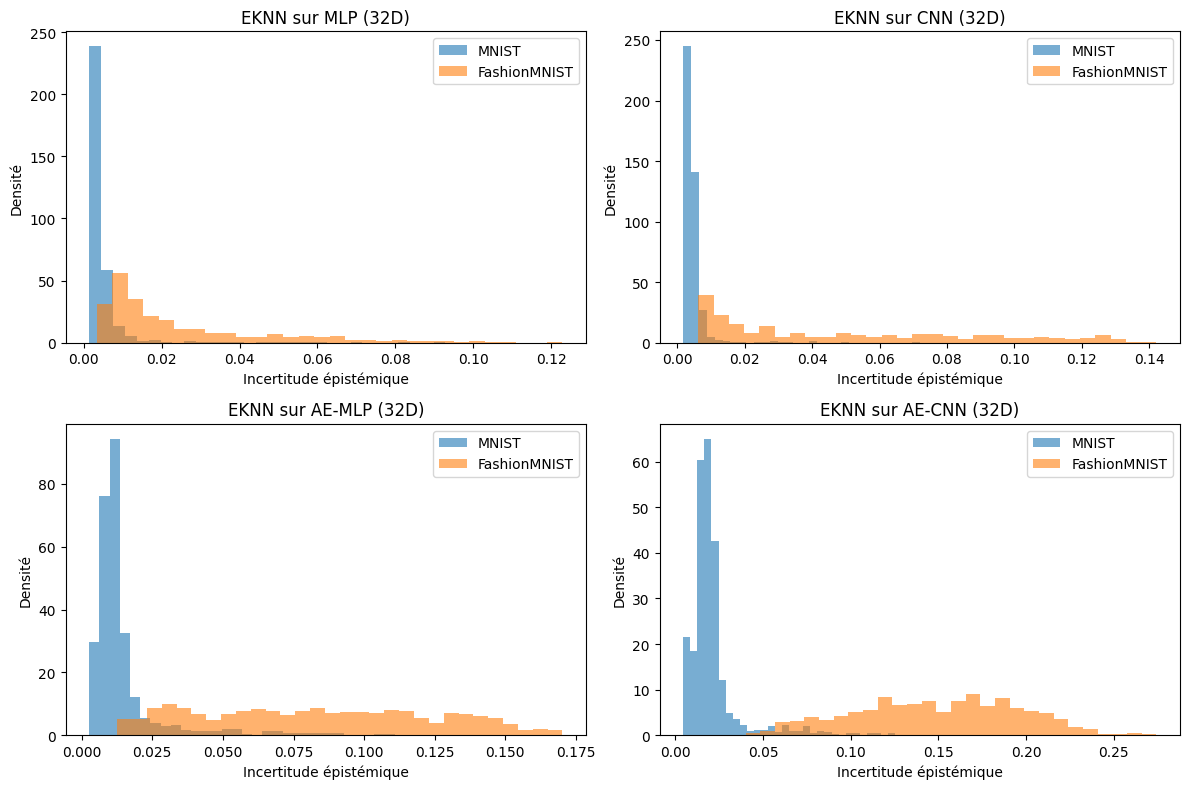

In [ ]:
# EKNN sur représentations 32D + incertitude épistémique (MNIST vs Fashion 1k)
from torch.utils.data import Subset
from sklearn.neighbors import NearestNeighbors
import math

class EKNNInline:
    def __init__(self, n_classes, n_neighbors=15, alpha=0.4, beta=0.5, random_state=0):
        self.n_classes = n_classes
        self.n_neighbors = n_neighbors
        self.alpha = alpha
        self.beta = beta
        self.random_state = random_state
        self._fitted = False

    def fit(self, X, y):
        self.X = X
        self.y = y.astype(int)
        self.nn = NearestNeighbors(n_neighbors=self.n_neighbors, metric="euclidean")
        self.nn.fit(self.X)
        self.gamma = self._compute_gamma(self.X)
        self._fitted = True
        return self

    def _compute_gamma(self, X):
        rng = np.random.default_rng(self.random_state)
        n = X.shape[0]
        m = min(10000, max(2, n // 2))
        idx = rng.choice(n, size=(m, 2), replace=False)
        distances = np.linalg.norm(X[idx[:, 0]] - X[idx[:, 1]], axis=1)
        mean_distance = np.nanmean(distances)
        return 1.0 / (mean_distance ** self.beta + 1e-12)

    def _combine_masses(self, m1, m2):
        # Dempster's rule for singletons + ignorance
        K = (1 - m1[-1]) * (1 - m2[-1]) - np.sum(m1[:-1] * m2[:-1])
        denom = 1 - K if (1 - K) > 1e-12 else 1e-12
        m = np.zeros_like(m1)
        m[:-1] = (m1[:-1] * m2[:-1] + m1[:-1] * m2[-1] + m1[-1] * m2[:-1]) / denom
        m[-1] = (m1[-1] * m2[-1]) / denom
        return m

    def _bba_for_sample(self, distances, indices):
        masses = []
        for d, idx in zip(distances, indices):
            m = np.zeros(self.n_classes + 1, dtype=np.float64)
            w = self.alpha * math.exp(-self.gamma * (d ** self.beta))
            cls = self.y[idx]
            m[cls] = w
            m[-1] = 1 - w
            masses.append(m)
        # Combine all neighbors
        m_comb = masses[0]
        for m in masses[1:]:
            m_comb = self._combine_masses(m_comb, m)
        return m_comb

    def get_uncertainties(self, X):
        if not self._fitted:
            raise RuntimeError("EKNNInline must be fitted before calling get_uncertainties.")
        distances, indices = self.nn.kneighbors(X, return_distance=True)
        bbas = np.zeros((X.shape[0], self.n_classes + 1), dtype=np.float64)
        for i in range(X.shape[0]):
            bbas[i] = self._bba_for_sample(distances[i], indices[i])
        # Epistemic: masse sur l'ignorance
        epistemic = bbas[:, -1]
        # Aleatoric: entropie de la proba pignistique
        betp = bbas[:, :-1] + bbas[:, -1][:, None] / self.n_classes
        betp = np.clip(betp, 1e-12, 1.0)
        aleatoric = -np.sum(betp * np.log2(betp), axis=1)
        return aleatoric, epistemic

rng = np.random.default_rng(2)
mnist_idx_1k = rng.choice(len(mnist_test), size=1000, replace=False)
fashion_idx_1k = rng.choice(len(fashion_test), size=1000, replace=False)

mnist_subset_1k = Subset(mnist_test, mnist_idx_1k)
fashion_subset_1k = Subset(fashion_test, fashion_idx_1k)

mnist_loader_1k = DataLoader(mnist_subset_1k, batch_size=256, shuffle=False)
fashion_loader_1k = DataLoader(fashion_subset_1k, batch_size=256, shuffle=False)

# Extraire représentations 32D pour MNIST 1k et Fashion 1k
X_mlp_mnist_1k, y_mnist_1k = extract_mlp_features(mlp_mnist, mnist_loader_1k)
X_cnn_mnist_1k, y_cnn_mnist_1k = extract_cnn_features(cnn_mnist, mnist_loader_1k)
X_ae_mlp_mnist_1k, y_ae_mlp_mnist_1k = extract_ae_mlp_features(ae_mlp_mnist, mnist_loader_1k)
X_ae_cnn_mnist_1k, y_ae_cnn_mnist_1k = extract_ae_cnn_features(ae_cnn_mnist, mnist_loader_1k)

X_mlp_fashion_1k, y_fashion_1k = extract_mlp_features(mlp_mnist, fashion_loader_1k)
X_cnn_fashion_1k, y_cnn_fashion_1k = extract_cnn_features(cnn_mnist, fashion_loader_1k)
X_ae_mlp_fashion_1k, y_ae_mlp_fashion_1k = extract_ae_mlp_features(ae_mlp_mnist, fashion_loader_1k)
X_ae_cnn_fashion_1k, y_ae_cnn_fashion_1k = extract_ae_cnn_features(ae_cnn_mnist, fashion_loader_1k)

# Conversion en numpy
X_mlp_train = X_mlp_full.numpy()
X_cnn_train = X_cnn_full.numpy()
X_ae_mlp_train = X_ae_mlp_full.numpy()
X_ae_cnn_train = X_ae_cnn_full.numpy()
y_train = y_full.numpy()

X_mlp_mnist_1k_np = X_mlp_mnist_1k.numpy()
X_cnn_mnist_1k_np = X_cnn_mnist_1k.numpy()
X_ae_mlp_mnist_1k_np = X_ae_mlp_mnist_1k.numpy()
X_ae_cnn_mnist_1k_np = X_ae_cnn_mnist_1k.numpy()

X_mlp_fashion_1k_np = X_mlp_fashion_1k.numpy()
X_cnn_fashion_1k_np = X_cnn_fashion_1k.numpy()
X_ae_mlp_fashion_1k_np = X_ae_mlp_fashion_1k.numpy()
X_ae_cnn_fashion_1k_np = X_ae_cnn_fashion_1k.numpy()

# Entraîner 4 EKNN
n_neighbors = 15
eknn_mlp = EKNNInline(n_classes=10, n_neighbors=n_neighbors)
eknn_cnn = EKNNInline(n_classes=10, n_neighbors=n_neighbors)
eknn_ae_mlp = EKNNInline(n_classes=10, n_neighbors=n_neighbors)
eknn_ae_cnn = EKNNInline(n_classes=10, n_neighbors=n_neighbors)

eknn_mlp.fit(X_mlp_train, y_train)
eknn_cnn.fit(X_cnn_train, y_train)
eknn_ae_mlp.fit(X_ae_mlp_train, y_train)
eknn_ae_cnn.fit(X_ae_cnn_train, y_train)

# Incertitude épistémique EKNN
_, ep_mlp_mnist = eknn_mlp.get_uncertainties(X_mlp_mnist_1k_np)
_, ep_mlp_fashion = eknn_mlp.get_uncertainties(X_mlp_fashion_1k_np)

_, ep_cnn_mnist = eknn_cnn.get_uncertainties(X_cnn_mnist_1k_np)
_, ep_cnn_fashion = eknn_cnn.get_uncertainties(X_cnn_fashion_1k_np)

_, ep_ae_mlp_mnist = eknn_ae_mlp.get_uncertainties(X_ae_mlp_mnist_1k_np)
_, ep_ae_mlp_fashion = eknn_ae_mlp.get_uncertainties(X_ae_mlp_fashion_1k_np)

_, ep_ae_cnn_mnist = eknn_ae_cnn.get_uncertainties(X_ae_cnn_mnist_1k_np)
_, ep_ae_cnn_fashion = eknn_ae_cnn.get_uncertainties(X_ae_cnn_fashion_1k_np)

# Graphes de densité (MNIST vs Fashion 1k)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], ep_mlp_mnist, ep_mlp_fashion, "EKNN sur MLP (32D)"),
    (axes[0, 1], ep_cnn_mnist, ep_cnn_fashion, "EKNN sur CNN (32D)"),
    (axes[1, 0], ep_ae_mlp_mnist, ep_ae_mlp_fashion, "EKNN sur AE-MLP (32D)"),
    (axes[1, 1], ep_ae_cnn_mnist, ep_ae_cnn_fashion, "EKNN sur AE-CNN (32D)")
]

for ax, ep_mnist, ep_fashion, title in plots:
    ax.hist(ep_mnist, bins=30, density=True, alpha=0.6, label="MNIST")
    ax.hist(ep_fashion, bins=30, density=True, alpha=0.6, label="FashionMNIST")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()

### Bayesian Logistic Regression

C:\Users\François\AppData\Local\Temp\ipykernel_36700\3593649720.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mnist_mlp_32 = torch.load(os.path.join(rep_dir, "mnist_ml

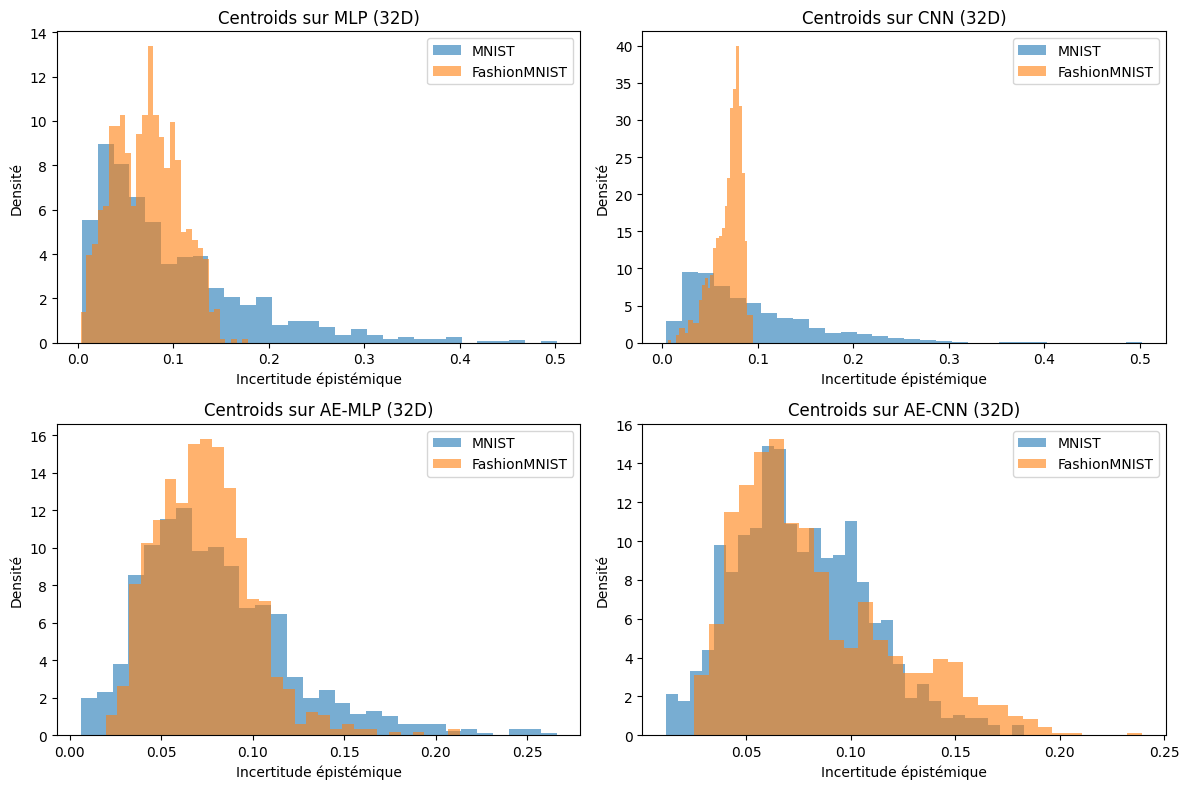

In [21]:
# Random Forest en chargeant les datasets 32D depuis le disque
import os
import torch
import numpy as np

rep_dir = os.path.join(data_root, "representations_32")
mnist_mlp_32 = torch.load(os.path.join(rep_dir, "mnist_mlp_32.pt"))
mnist_cnn_32 = torch.load(os.path.join(rep_dir, "mnist_cnn_32.pt"))
mnist_ae_mlp_32 = torch.load(os.path.join(rep_dir, "mnist_ae_mlp_32.pt"))
mnist_ae_cnn_32 = torch.load(os.path.join(rep_dir, "mnist_ae_cnn_32.pt"))
fashion_mlp_32_1k = torch.load(os.path.join(rep_dir, "fashion_mlp_32_1k.pt"))
fashion_cnn_32_1k = torch.load(os.path.join(rep_dir, "fashion_cnn_32_1k.pt"))
fashion_ae_mlp_32_1k = torch.load(os.path.join(rep_dir, "fashion_ae_mlp_32_1k.pt"))
fashion_ae_cnn_32_1k = torch.load(os.path.join(rep_dir, "fashion_ae_cnn_32_1k.pt"))

# Données d'entraînement (MNIST complet en 32D)
X_mlp_train = mnist_mlp_32.tensors[0].numpy()
X_cnn_train = mnist_cnn_32.tensors[0].numpy()
X_ae_mlp_train = mnist_ae_mlp_32.tensors[0].numpy()
X_ae_cnn_train = mnist_ae_cnn_32.tensors[0].numpy()
y_train = mnist_mlp_32.tensors[1].numpy()

# MNIST 1k (échantillonnage depuis les représentations 32D sauvegardées)
rng = np.random.default_rng(1)
mnist_idx_1k = rng.choice(len(y_train), size=1000, replace=False)
X_mlp_mnist_1k_np = mnist_mlp_32.tensors[0][mnist_idx_1k].numpy()
X_cnn_mnist_1k_np = mnist_cnn_32.tensors[0][mnist_idx_1k].numpy()
X_ae_mlp_mnist_1k_np = mnist_ae_mlp_32.tensors[0][mnist_idx_1k].numpy()
X_ae_cnn_mnist_1k_np = mnist_ae_cnn_32.tensors[0][mnist_idx_1k].numpy()

# Fashion 1k (déjà sauvegardé en 32D)
X_mlp_fashion_1k_np = fashion_mlp_32_1k.tensors[0].numpy()
X_cnn_fashion_1k_np = fashion_cnn_32_1k.tensors[0].numpy()
X_ae_mlp_fashion_1k_np = fashion_ae_mlp_32_1k.tensors[0].numpy()
X_ae_cnn_fashion_1k_np = fashion_ae_cnn_32_1k.tensors[0].numpy()

def centroids_uncertainties(X, y, X_test, length_scale=10):
    unique_classes = np.unique(y)
    centroids = {}
    for cls in unique_classes:
        cls_positions = X[y == cls]
        centroids[cls] = np.mean(cls_positions, axis=0)

    size = len(centroids)

    uncertainties = []
    for c in centroids:
        l2 = np.linalg.norm(X_test - centroids[c], ord=2, axis=1)
        l2 = (1/size) * (l2**2)
        l2 = l2 / (2 * length_scale)
        l2 = np.exp(-l2)
        uncertainties.append(l2)
    
    preds = uncertainties / np.sum(uncertainties, axis=0)
    preds = np.array(preds).T

    ep = - np.log(np.max(uncertainties, axis=0))
    ep = ep / (ep + (10.0 * np.median(ep))) * 0.8

    p_pred_0 = []
    for i in range(200):
        sample = np.random.normal(preds[:,0], np.sqrt(ep))
        sample = np.clip(sample, 0, 1)
        p_pred_0.append(sample)
    p_pred_0 = np.array(p_pred_0)
    p_pred = np.array([p_pred_0, 1-p_pred_0]).transpose(1, 2, 0)

    return ep, p_pred, preds


ep_mlp_mnist, _, _ = centroids_uncertainties(X_mlp_train, y_train, X_mlp_mnist_1k_np)
ep_mlp_fashion, _, _ = centroids_uncertainties(X_mlp_train, y_train, X_mlp_fashion_1k_np)

ep_cnn_mnist, _, _ = centroids_uncertainties(X_cnn_train, y_train, X_cnn_mnist_1k_np)
ep_cnn_fashion, _, _ = centroids_uncertainties(X_cnn_train, y_train, X_cnn_fashion_1k_np)

ep_ae_mlp_mnist, _, _ = centroids_uncertainties(X_ae_mlp_train, y_train, X_ae_mlp_mnist_1k_np)
ep_ae_mlp_fashion, _, _ = centroids_uncertainties(X_ae_mlp_train, y_train, X_ae_mlp_fashion_1k_np)

ep_ae_cnn_mnist, _, _ = centroids_uncertainties(X_ae_cnn_train, y_train, X_ae_cnn_mnist_1k_np)
ep_ae_cnn_fashion, _, _ = centroids_uncertainties(X_ae_cnn_train, y_train, X_ae_cnn_fashion_1k_np)

# Graphes de densité (MNIST vs Fashion 1k)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], ep_mlp_mnist, ep_mlp_fashion, "Centroids sur MLP (32D)"),
    (axes[0, 1], ep_cnn_mnist, ep_cnn_fashion, "Centroids sur CNN (32D)"),
    (axes[1, 0], ep_ae_mlp_mnist, ep_ae_mlp_fashion, "Centroids sur AE-MLP (32D)"),
    (axes[1, 1], ep_ae_cnn_mnist, ep_ae_cnn_fashion, "Centroids sur AE-CNN (32D)")
]

for ax, ep_mnist, ep_fashion, title in plots:
    ax.hist(ep_mnist, bins=30, density=True, alpha=0.6, label="MNIST")
    ax.hist(ep_fashion, bins=30, density=True, alpha=0.6, label="FashionMNIST")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()

c:\Users\François\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\François\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.

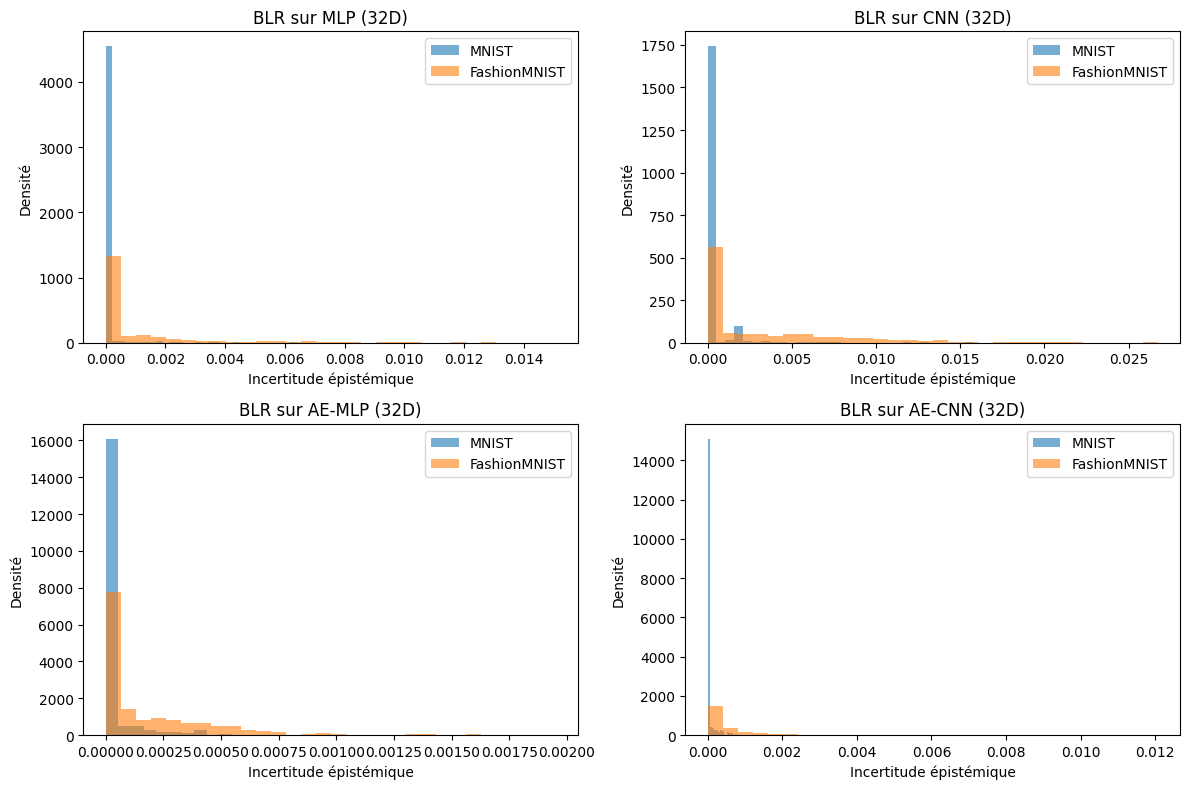

In [ ]:
# Bayesian Logistic Regression (approx. Laplace) sur 32D + incertitude épistémique
from torch.utils.data import Subset
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(3)
mnist_idx_1k = rng.choice(len(mnist_test), size=1000, replace=False)
fashion_idx_1k = rng.choice(len(fashion_test), size=1000, replace=False)

mnist_subset_1k = Subset(mnist_test, mnist_idx_1k)
fashion_subset_1k = Subset(fashion_test, fashion_idx_1k)

mnist_loader_1k = DataLoader(mnist_subset_1k, batch_size=256, shuffle=False)
fashion_loader_1k = DataLoader(fashion_subset_1k, batch_size=256, shuffle=False)

# Extraire représentations 32D pour MNIST 1k et Fashion 1k
X_mlp_mnist_1k, y_mnist_1k = extract_mlp_features(mlp_mnist, mnist_loader_1k)
X_cnn_mnist_1k, y_cnn_mnist_1k = extract_cnn_features(cnn_mnist, mnist_loader_1k)
X_ae_mlp_mnist_1k, y_ae_mlp_mnist_1k = extract_ae_mlp_features(ae_mlp_mnist, mnist_loader_1k)
X_ae_cnn_mnist_1k, y_ae_cnn_mnist_1k = extract_ae_cnn_features(ae_cnn_mnist, mnist_loader_1k)

X_mlp_fashion_1k, y_fashion_1k = extract_mlp_features(mlp_mnist, fashion_loader_1k)
X_cnn_fashion_1k, y_cnn_fashion_1k = extract_cnn_features(cnn_mnist, fashion_loader_1k)
X_ae_mlp_fashion_1k, y_ae_mlp_fashion_1k = extract_ae_mlp_features(ae_mlp_mnist, fashion_loader_1k)
X_ae_cnn_fashion_1k, y_ae_cnn_fashion_1k = extract_ae_cnn_features(ae_cnn_mnist, fashion_loader_1k)

# Conversion en numpy
X_mlp_train = X_mlp_full.numpy()
X_cnn_train = X_cnn_full.numpy()
X_ae_mlp_train = X_ae_mlp_full.numpy()
X_ae_cnn_train = X_ae_cnn_full.numpy()
y_train = y_full.numpy()

X_mlp_mnist_1k_np = X_mlp_mnist_1k.numpy()
X_cnn_mnist_1k_np = X_cnn_mnist_1k.numpy()
X_ae_mlp_mnist_1k_np = X_ae_mlp_mnist_1k.numpy()
X_ae_cnn_mnist_1k_np = X_ae_cnn_mnist_1k.numpy()

X_mlp_fashion_1k_np = X_mlp_fashion_1k.numpy()
X_cnn_fashion_1k_np = X_cnn_fashion_1k.numpy()
X_ae_mlp_fashion_1k_np = X_ae_mlp_fashion_1k.numpy()
X_ae_cnn_fashion_1k_np = X_ae_cnn_fashion_1k.numpy()

def _sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def bayes_logreg_epistemic(X_train, y_train, X_test, n_classes=10, prior_precision=1.0, n_samples=100, seed=0):
    X_train = X_train.astype(np.float64)
    X_test = X_test.astype(np.float64)
    y_train = y_train.astype(int)

    X_aug = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
    X_test_aug = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

    weights = []
    covs = []
    for c in range(n_classes):
        y_bin = (y_train == c).astype(int)
        clf = LogisticRegression(max_iter=200, solver="lbfgs")
        clf.fit(X_train, y_bin)
        w = np.concatenate([clf.coef_.ravel(), clf.intercept_])
        logits = X_aug @ w
        p = _sigmoid(logits)
        W = p * (1 - p)
        H = (X_aug.T * W) @ X_aug + prior_precision * np.eye(X_aug.shape[1])
        cov = np.linalg.inv(H)
        weights.append(w)
        covs.append(cov)

    rng_local = np.random.default_rng(seed)
    W_samples = np.stack(
        [rng_local.multivariate_normal(weights[c], covs[c], size=n_samples) for c in range(n_classes)],
        axis=1
    )
    # logits_samples: (n_samples, n_classes, n_points)
    logits_samples = np.einsum("nd,skd->skn", X_test_aug, W_samples)
    logits_samples = np.transpose(logits_samples, (0, 2, 1))  # (n_samples, n_points, n_classes)

    logits_samples = logits_samples - logits_samples.max(axis=2, keepdims=True)
    exp_logits = np.exp(logits_samples)
    probs_samples = exp_logits / exp_logits.sum(axis=2, keepdims=True)

    ep = np.var(probs_samples, axis=0).mean(axis=1)
    return ep

# Epistémique pour MNIST 1k et Fashion 1k
blr_ep_mlp_mnist = bayes_logreg_epistemic(X_mlp_train, y_train, X_mlp_mnist_1k_np, seed=0)
blr_ep_mlp_fashion = bayes_logreg_epistemic(X_mlp_train, y_train, X_mlp_fashion_1k_np, seed=0)

blr_ep_cnn_mnist = bayes_logreg_epistemic(X_cnn_train, y_train, X_cnn_mnist_1k_np, seed=1)
blr_ep_cnn_fashion = bayes_logreg_epistemic(X_cnn_train, y_train, X_cnn_fashion_1k_np, seed=1)

blr_ep_ae_mlp_mnist = bayes_logreg_epistemic(X_ae_mlp_train, y_train, X_ae_mlp_mnist_1k_np, seed=2)
blr_ep_ae_mlp_fashion = bayes_logreg_epistemic(X_ae_mlp_train, y_train, X_ae_mlp_fashion_1k_np, seed=2)

blr_ep_ae_cnn_mnist = bayes_logreg_epistemic(X_ae_cnn_train, y_train, X_ae_cnn_mnist_1k_np, seed=3)
blr_ep_ae_cnn_fashion = bayes_logreg_epistemic(X_ae_cnn_train, y_train, X_ae_cnn_fashion_1k_np, seed=3)

# Graphes de densité (MNIST vs Fashion 1k)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], blr_ep_mlp_mnist, blr_ep_mlp_fashion, "BLR sur MLP (32D)"),
    (axes[0, 1], blr_ep_cnn_mnist, blr_ep_cnn_fashion, "BLR sur CNN (32D)"),
    (axes[1, 0], blr_ep_ae_mlp_mnist, blr_ep_ae_mlp_fashion, "BLR sur AE-MLP (32D)"),
    (axes[1, 1], blr_ep_ae_cnn_mnist, blr_ep_ae_cnn_fashion, "BLR sur AE-CNN (32D)")
]

for ax, ep_mnist, ep_fashion, title in plots:
    ax.hist(ep_mnist, bins=30, density=True, alpha=0.6, label="MNIST")
    ax.hist(ep_fashion, bins=30, density=True, alpha=0.6, label="FashionMNIST")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()

# Demo on CIFAR90 (OOD = CIFAR10)

## Loading the dataset

100%|██████████| 169M/169M [00:55<00:00, 3.06MB/s] 


Extracting ./dataset\cifar-100-python.tar.gz to ./dataset
Files already downloaded and verified


100%|██████████| 170M/170M [01:43<00:00, 1.64MB/s] 


Extracting ./dataset\cifar-10-python.tar.gz to ./dataset
Files already downloaded and verified


Loading CIFAR10: 100%|██████████| 10/10 [00:00<00:00, 92.90it/s]


CIFAR90 (train, test) : 45000, 9000
CIFAR10 (train, test) : 50000, 10000
Examples of CIFAR90 and CIFAR10 images:


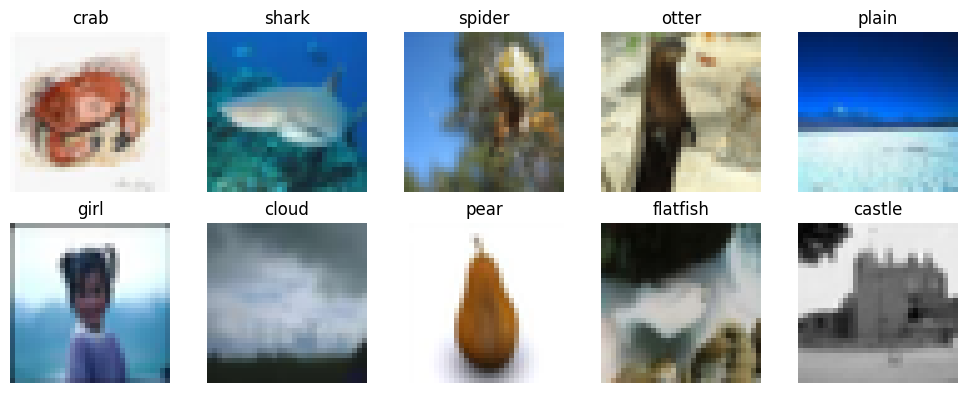

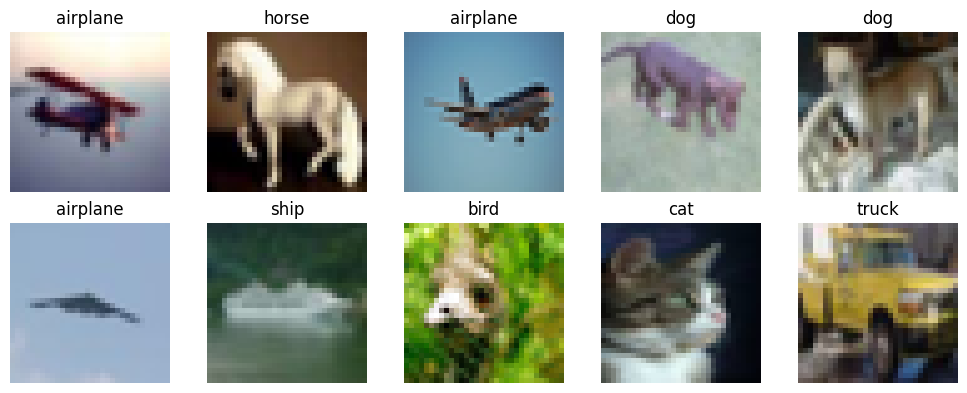

In [3]:
data_root = "./dataset"
batch_size = 128

cifar_mean = (0.5071, 0.4867, 0.4408)
cifar_std = (0.2675, 0.2565, 0.2761)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])

cifar100_train = datasets.CIFAR100(root=data_root, train=True, download=True, transform=transform)
cifar100_test = datasets.CIFAR100(root=data_root, train=False, download=True, transform=transform)

excluded_classes = list(range(10))
keep_classes = [c for c in range(100) if c not in excluded_classes]

class CIFAR90(torch.utils.data.Dataset):
    def __init__(self, base, keep_classes):
        self.base = base
        self.keep_classes = sorted(keep_classes)
        self.class_to_idx = {c: i for i, c in enumerate(self.keep_classes)}
        self.indices = [i for i, t in enumerate(base.targets) if t in self.keep_classes]
        self.classes = [base.classes[c] for c in self.keep_classes]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, target = self.base[self.indices[idx]]
        return img, self.class_to_idx[target]

cifar90_train = CIFAR90(cifar100_train, keep_classes)
cifar90_test = CIFAR90(cifar100_test, keep_classes)

cifar10_train = datasets.CIFAR10(root=data_root, train=True, download=True, transform=transform)
cifar10_test = datasets.CIFAR10(root=data_root, train=False, download=True, transform=transform)

cifar90_train_loader = DataLoader(cifar90_train, batch_size=batch_size, shuffle=True)
cifar90_test_loader = DataLoader(cifar90_test, batch_size=batch_size, shuffle=False)

cifar10_train_loader = DataLoader(cifar10_train, batch_size=batch_size, shuffle=True)
cifar10_test_loader = DataLoader(cifar10_test, batch_size=batch_size, shuffle=False)

# Loading bar
for _ in tqdm(islice(cifar90_train_loader, 10), total=10, desc="Loading CIFAR90"):
    pass
for _ in tqdm(islice(cifar10_train_loader, 10), total=10, desc="Loading CIFAR10"):
    pass

print(f"CIFAR90 (train, test) : {len(cifar90_train)}, {len(cifar90_test)}\nCIFAR10 (train, test) : {len(cifar10_train)}, {len(cifar10_test)}")

print("Examples of CIFAR90 and CIFAR10 images:")

cifar90_classes = cifar90_train.classes
cifar10_classes = cifar10_train.classes

# Display 10 random CIFAR90 images with their labels
idx = np.random.choice(len(cifar90_train), size=10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

def _denorm(img):
    mean = torch.tensor(cifar_mean)[:, None, None]
    std = torch.tensor(cifar_std)[:, None, None]
    return img * std + mean

for ax, i in zip(axes, idx):
    img, label = cifar90_train[i]
    img = _denorm(img).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(cifar90_classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Display 10 random CIFAR10 images with their labels
idx = np.random.choice(len(cifar10_train), size=10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

for ax, i in zip(axes, idx):
    img, label = cifar10_train[i]
    img = _denorm(img).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(cifar10_classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Training our models

### Supervised Learning : Multi-Layer Perceptron

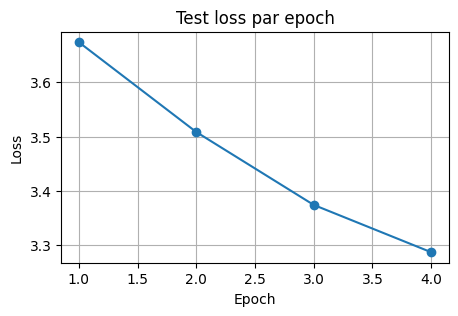

MLP_CIFAR90(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=32, bias=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=90, bias=True)
  )
)


In [4]:
# Entraînement d'un MLP sur GPU (si dispo)
from IPython.display import clear_output, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class MLP_CIFAR90(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 3, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 90)
        )

    def forward(self, x):
        return self.net(x)

mlp_cifar90 = MLP_CIFAR90().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_cifar90.parameters(), lr=1e-3)

epochs = 4
test_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    mlp_cifar90.train()
    running_loss = 0.0
    for x, y in tqdm(cifar90_train_loader, desc=f"Epoch {epoch}"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = mlp_cifar90(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(cifar90_train_loader.dataset)

    mlp_cifar90.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    with torch.no_grad():
        for x, y in cifar90_test_loader:
            x, y = x.to(device), y.to(device)
            logits = mlp_cifar90(x)
            loss = criterion(logits, y)
            test_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    test_loss = test_loss / len(cifar90_test_loader.dataset)
    test_losses.append(test_loss)
    acc = correct / total
    print(f"Epoch {epoch} - loss: {train_loss:.4f} - val_loss: {test_loss:.4f} - acc: {acc:.4f}")

    # Actualisation du même graphe (taille fixe)
    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(test_losses) + 1), test_losses, marker="o")
    ax.set_title("Test loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(mlp_cifar90)

### Supervised Learning : Convolutional Neural Network

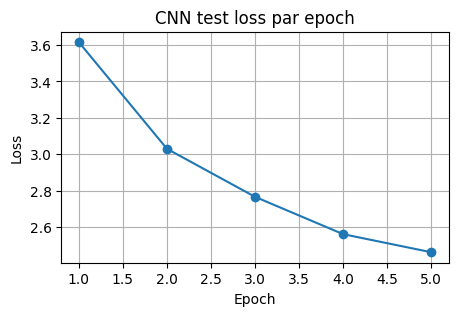

CNN_CIFAR90(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=32, bias=True)
    (6): ReLU()
    (7): Linear(in_features=32, out_features=90, bias=True)
  )
)


In [5]:
# Entraînement d'un CNN sur GPU (si dispo)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class CNN_CIFAR90(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 32), nn.ReLU(),
            nn.Linear(32, 90)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn_cifar90 = CNN_CIFAR90().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_cifar90.parameters(), lr=1e-3)

epochs = 5
test_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    cnn_cifar90.train()
    running_loss = 0.0
    for x, y in tqdm(cifar90_train_loader, desc=f"CNN Epoch {epoch}"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = cnn_cifar90(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(cifar90_train_loader.dataset)

    cnn_cifar90.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    with torch.no_grad():
        for x, y in cifar90_test_loader:
            x, y = x.to(device), y.to(device)
            logits = cnn_cifar90(x)
            loss = criterion(logits, y)
            test_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    test_loss = test_loss / len(cifar90_test_loader.dataset)
    test_losses.append(test_loss)
    acc = correct / total
    print(f"CNN Epoch {epoch} - loss: {train_loss:.4f} - val_loss: {test_loss:.4f} - acc: {acc:.4f}")

    # Actualisation du même graphe (taille fixe)
    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(test_losses) + 1), test_losses, marker="o")
    ax.set_title("CNN test loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(cnn_cifar90)

### Unsupervised Learning : MLP Auto-Encoder

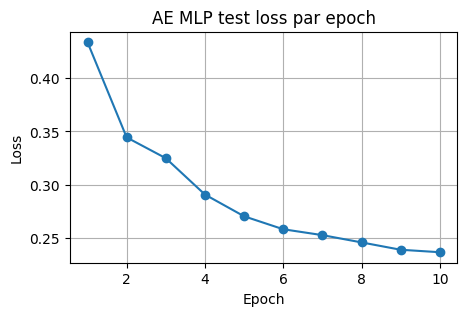

AE_MLP_CIFAR90(
  (encoder): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=512, bias=True)
    (7): ReLU()
    (8): Linear(in_features=512, out_features=3072, bias=True)
  )
)


In [6]:
# Entraînement d'un Auto-Encodeur MLP (miroir) sur GPU (si dispo)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class AE_MLP_CIFAR90(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(32 * 32 * 3, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 32 * 32 * 3)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

ae_mlp_cifar90 = AE_MLP_CIFAR90().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_mlp_cifar90.parameters(), lr=1e-3)

epochs = 10
test_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    ae_mlp_cifar90.train()
    running_loss = 0.0
    for x, _ in tqdm(cifar90_train_loader, desc=f"AE Epoch {epoch}"):
        x = x.to(device)
        x_flat = x.view(x.size(0), -1)
        optimizer.zero_grad()
        recon = ae_mlp_cifar90(x_flat)
        loss = criterion(recon, x_flat)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(cifar90_train_loader.dataset)

    ae_mlp_cifar90.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x, _ in cifar90_test_loader:
            x = x.to(device)
            x_flat = x.view(x.size(0), -1)
            recon = ae_mlp_cifar90(x_flat)
            loss = criterion(recon, x_flat)
            test_loss += loss.item() * x.size(0)
    test_loss = test_loss / len(cifar90_test_loader.dataset)
    test_losses.append(test_loss)
    print(f"AE Epoch {epoch} - loss: {train_loss:.4f} - val_loss: {test_loss:.4f}")

    # Actualisation du même graphe (taille fixe)
    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(test_losses) + 1), test_losses, marker="o")
    ax.set_title("AE MLP test loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(ae_mlp_cifar90)

### Unsupervised Learning : CNN Auto-Encoder

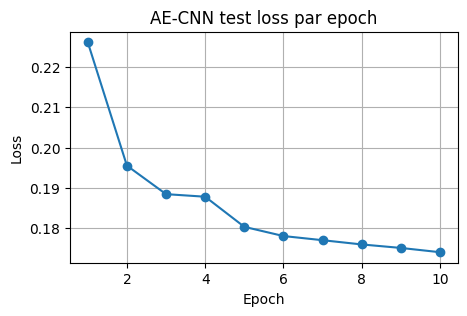

AE_CNN_CIFAR90(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bottleneck): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=32, bias=True)
  )
  (unbottleneck): Sequential(
    (0): Linear(in_features=32, out_features=8192, bias=True)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)

In [7]:
# Entraînement d'un Auto-Encodeur CNN (miroir) sur GPU (si dispo)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class AE_CNN_CIFAR90(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.bottleneck = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 32)
        )
        self.unbottleneck = nn.Sequential(
            nn.Linear(32, 128 * 8 * 8),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2), nn.ReLU(),
            nn.Conv2d(32, 3, kernel_size=3, padding=1)
        )

    def forward(self, x):
        x = self.encoder(x)
        z = self.bottleneck(x)
        x = self.unbottleneck(z).view(-1, 128, 8, 8)
        x = self.decoder(x)
        return x

ae_cnn_cifar90 = AE_CNN_CIFAR90().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_cnn_cifar90.parameters(), lr=1e-3)

epochs = 10
test_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    ae_cnn_cifar90.train()
    running_loss = 0.0
    for x, _ in tqdm(cifar90_train_loader, desc=f"AE-CNN Epoch {epoch}"):
        x = x.to(device)
        optimizer.zero_grad()
        recon = ae_cnn_cifar90(x)
        loss = criterion(recon, x)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(cifar90_train_loader.dataset)

    ae_cnn_cifar90.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x, _ in cifar90_test_loader:
            x = x.to(device)
            recon = ae_cnn_cifar90(x)
            loss = criterion(recon, x)
            test_loss += loss.item() * x.size(0)
    test_loss = test_loss / len(cifar90_test_loader.dataset)
    test_losses.append(test_loss)
    print(f"AE-CNN Epoch {epoch} - loss: {train_loss:.4f} - val_loss: {test_loss:.4f}")

    # Actualisation du même graphe (taille fixe)
    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(test_losses) + 1), test_losses, marker="o")
    ax.set_title("AE-CNN test loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(ae_cnn_cifar90)

### Model performance comparaison

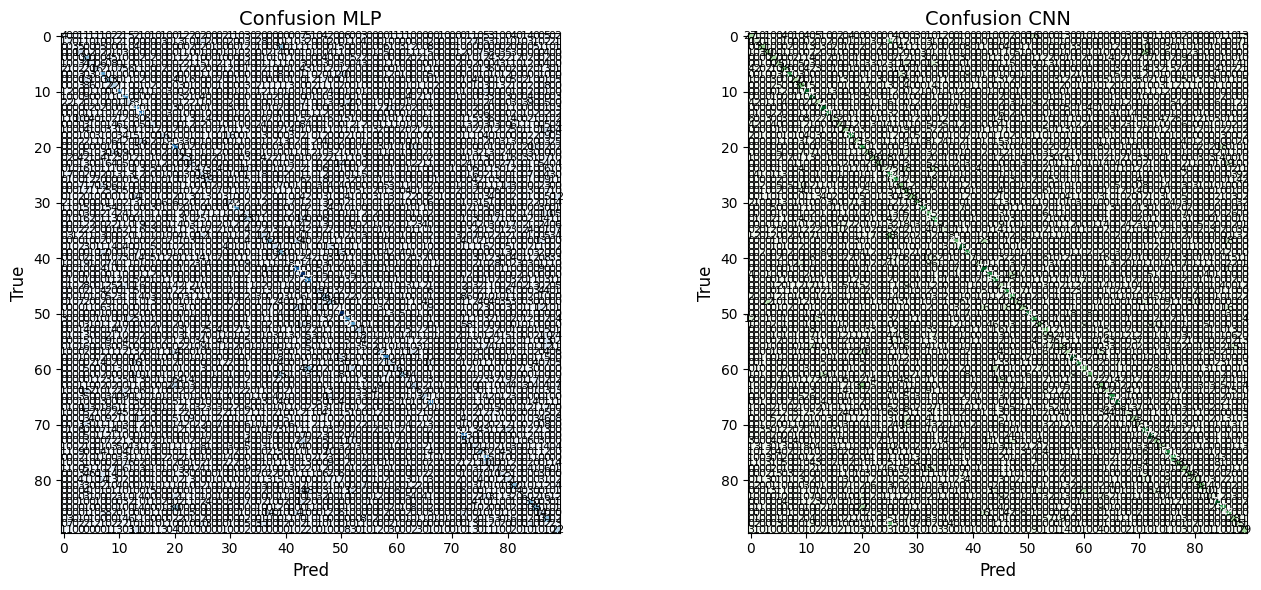

,model,accuracy,precision_macro,recall_macro,f1_macro
0,MLP,0.206444,0.196091,0.206444,0.179449
1,CNN,0.366444,0.385158,0.366444,0.355208


In [8]:
# Comparaison MLP vs CNN sur le test set
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_cifar90.eval()
cnn_cifar90.eval()

y_true = []
y_pred_mlp = []
y_pred_cnn = []

with torch.no_grad():
    for x, y in cifar90_test_loader:
        x = x.to(device)
        logits_mlp = mlp_cifar90(x)
        logits_cnn = cnn_cifar90(x)
        y_true.extend(y.numpy().tolist())
        y_pred_mlp.extend(logits_mlp.argmax(dim=1).cpu().numpy().tolist())
        y_pred_cnn.extend(logits_cnn.argmax(dim=1).cpu().numpy().tolist())

cm_mlp = confusion_matrix(y_true, y_pred_mlp)
cm_cnn = confusion_matrix(y_true, y_pred_cnn)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cm_mlp, cmap="Blues")
axes[0].set_title("Confusion MLP", fontsize=14)
axes[0].set_xlabel("Pred", fontsize=12)
axes[0].set_ylabel("True", fontsize=12)
axes[1].imshow(cm_cnn, cmap="Greens")
axes[1].set_title("Confusion CNN", fontsize=14)
axes[1].set_xlabel("Pred", fontsize=12)
axes[1].set_ylabel("True", fontsize=12)

# Afficher les valeurs dans chaque case
for i in range(cm_mlp.shape[0]):
    for j in range(cm_mlp.shape[1]):
        axes[0].text(j, i, cm_mlp[i, j], ha="center", va="center", fontsize=8,
                     color="white" if cm_mlp[i, j] > cm_mlp.max() / 2 else "black")
for i in range(cm_cnn.shape[0]):
    for j in range(cm_cnn.shape[1]):
        axes[1].text(j, i, cm_cnn[i, j], ha="center", va="center", fontsize=8,
                     color="white" if cm_cnn[i, j] > cm_cnn.max() / 2 else "black")

plt.tight_layout()
plt.show()

metrics = pd.DataFrame([
    {
        "model": "MLP",
        "accuracy": accuracy_score(y_true, y_pred_mlp),
        "precision_macro": precision_score(y_true, y_pred_mlp, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred_mlp, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred_mlp, average="macro", zero_division=0),
    },
    {
        "model": "CNN",
        "accuracy": accuracy_score(y_true, y_pred_cnn),
        "precision_macro": precision_score(y_true, y_pred_cnn, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred_cnn, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred_cnn, average="macro", zero_division=0),
    }
])

metrics

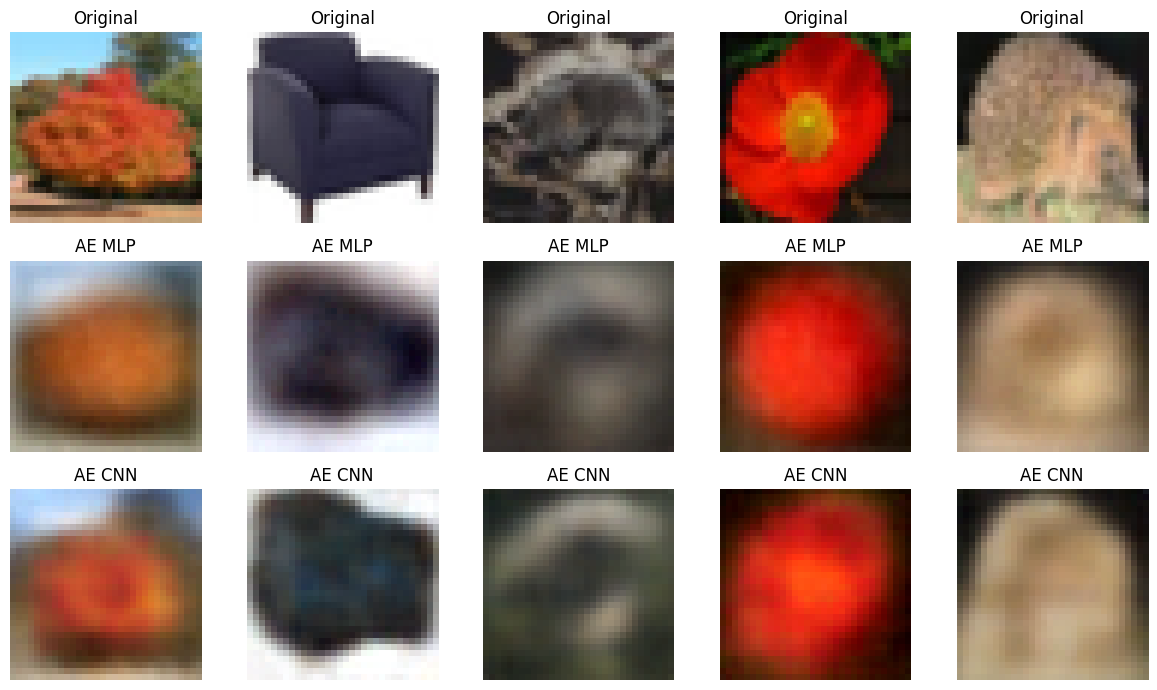

In [9]:
# Comparer les reconstructions des auto-encodeurs (5 images test)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ae_mlp_cifar90.eval()
ae_cnn_cifar90.eval()

idx = np.random.choice(len(cifar90_test), size=5, replace=False)
images = torch.stack([cifar90_test[i][0] for i in idx]).to(device)

with torch.no_grad():
    recon_mlp = ae_mlp_cifar90(images.view(images.size(0), -1)).view(-1, 3, 32, 32)
    recon_cnn = ae_cnn_cifar90(images)

images = images.cpu()
recon_mlp = recon_mlp.cpu()
recon_cnn = recon_cnn.cpu()

mean = torch.tensor(cifar_mean)[:, None, None]
std = torch.tensor(cifar_std)[:, None, None]

def _denorm(img):
    return img * std + mean

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for i in range(5):
    img = np.clip(_denorm(images[i]).permute(1, 2, 0).numpy(), 0, 1)
    rec_mlp = np.clip(_denorm(recon_mlp[i]).permute(1, 2, 0).numpy(), 0, 1)
    rec_cnn = np.clip(_denorm(recon_cnn[i]).permute(1, 2, 0).numpy(), 0, 1)

    axes[0, i].imshow(img)
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")
    axes[1, i].imshow(rec_mlp)
    axes[1, i].set_title("AE MLP")
    axes[1, i].axis("off")
    axes[2, i].imshow(rec_cnn)
    axes[2, i].set_title("AE CNN")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

## Uncertainty Quantification

### Save 32 neurons datasets

In [10]:
# Sauvegarde des datasets 32D pour tout CIFAR90 (train + test)
import os
from torch.utils.data import ConcatDataset

device = next(mlp_cifar90.parameters()).device

cifar90_full = ConcatDataset([cifar90_train, cifar90_test])
cifar90_full_loader = DataLoader(cifar90_full, batch_size=batch_size, shuffle=False)

@torch.no_grad()
def extract_mlp_features(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        f = model.net[:-1](x)
        feats.append(f.cpu())
        labels.append(y.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)

@torch.no_grad()
def extract_cnn_features(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        f = model.classifier[:-1](model.features(x))
        feats.append(f.cpu())
        labels.append(y.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)

@torch.no_grad()
def extract_ae_mlp_features(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        x_flat = x.view(x.size(0), -1)
        f = model.encoder(x_flat)
        feats.append(f.cpu())
        labels.append(y.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)

@torch.no_grad()
def extract_ae_cnn_features(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        f = model.bottleneck(model.encoder(x))
        feats.append(f.cpu())
        labels.append(y.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)

X_mlp_full, y_full = extract_mlp_features(mlp_cifar90, cifar90_full_loader)
X_cnn_full, y_cnn_full = extract_cnn_features(cnn_cifar90, cifar90_full_loader)
X_ae_mlp_full, y_ae_mlp_full = extract_ae_mlp_features(ae_mlp_cifar90, cifar90_full_loader)
X_ae_cnn_full, y_ae_cnn_full = extract_ae_cnn_features(ae_cnn_cifar90, cifar90_full_loader)

assert torch.equal(y_full, y_cnn_full)
assert torch.equal(y_full, y_ae_mlp_full)
assert torch.equal(y_full, y_ae_cnn_full)

cifar90_mlp_32 = TensorDataset(X_mlp_full, y_full)
cifar90_cnn_32 = TensorDataset(X_cnn_full, y_full)
cifar90_ae_mlp_32 = TensorDataset(X_ae_mlp_full, y_full)
cifar90_ae_cnn_32 = TensorDataset(X_ae_cnn_full, y_full)

out_dir = os.path.join(data_root, "representations_32")
os.makedirs(out_dir, exist_ok=True)

torch.save(cifar90_mlp_32, os.path.join(out_dir, "cifar90_mlp_32.pt"))
torch.save(cifar90_cnn_32, os.path.join(out_dir, "cifar90_cnn_32.pt"))
torch.save(cifar90_ae_mlp_32, os.path.join(out_dir, "cifar90_ae_mlp_32.pt"))
torch.save(cifar90_ae_cnn_32, os.path.join(out_dir, "cifar90_ae_cnn_32.pt"))

print("Sauvegarde OK:", out_dir)

Sauvegarde OK: ./dataset\representations_32


In [11]:
# Extraire et sauvegarder 1000 CIFAR10 (représentations 32D)
from torch.utils.data import Subset

rng = np.random.default_rng(0)
cifar10_idx_1k = rng.choice(len(cifar10_test), size=1000, replace=False)
cifar10_subset_1k = Subset(cifar10_test, cifar10_idx_1k)
cifar10_loader_1k = DataLoader(cifar10_subset_1k, batch_size=256, shuffle=False)

X_mlp_cifar10_1k, y_cifar10_1k = extract_mlp_features(mlp_cifar90, cifar10_loader_1k)
X_cnn_cifar10_1k, y_cnn_cifar10_1k = extract_cnn_features(cnn_cifar90, cifar10_loader_1k)
X_ae_mlp_cifar10_1k, y_ae_mlp_cifar10_1k = extract_ae_mlp_features(ae_mlp_cifar90, cifar10_loader_1k)
X_ae_cnn_cifar10_1k, y_ae_cnn_cifar10_1k = extract_ae_cnn_features(ae_cnn_cifar90, cifar10_loader_1k)

assert torch.equal(y_cifar10_1k, y_cnn_cifar10_1k)
assert torch.equal(y_cifar10_1k, y_ae_mlp_cifar10_1k)
assert torch.equal(y_cifar10_1k, y_ae_cnn_cifar10_1k)

cifar10_mlp_32_1k = TensorDataset(X_mlp_cifar10_1k, y_cifar10_1k)
cifar10_cnn_32_1k = TensorDataset(X_cnn_cifar10_1k, y_cifar10_1k)
cifar10_ae_mlp_32_1k = TensorDataset(X_ae_mlp_cifar10_1k, y_cifar10_1k)
cifar10_ae_cnn_32_1k = TensorDataset(X_ae_cnn_cifar10_1k, y_cifar10_1k)

out_dir = os.path.join(data_root, "representations_32")
os.makedirs(out_dir, exist_ok=True)

torch.save(cifar10_mlp_32_1k, os.path.join(out_dir, "cifar10_mlp_32_1k.pt"))
torch.save(cifar10_cnn_32_1k, os.path.join(out_dir, "cifar10_cnn_32_1k.pt"))
torch.save(cifar10_ae_mlp_32_1k, os.path.join(out_dir, "cifar10_ae_mlp_32_1k.pt"))
torch.save(cifar10_ae_cnn_32_1k, os.path.join(out_dir, "cifar10_ae_cnn_32_1k.pt"))

print("Sauvegarde OK (CIFAR10 1k):", out_dir)

Sauvegarde OK (CIFAR10 1k): ./dataset\representations_32


### Random forest

C:\Users\François\AppData\Local\Temp\ipykernel_37260\2182757976.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cifar90_mlp_32 = torch.load(os.path.join(rep_dir, "cifar9

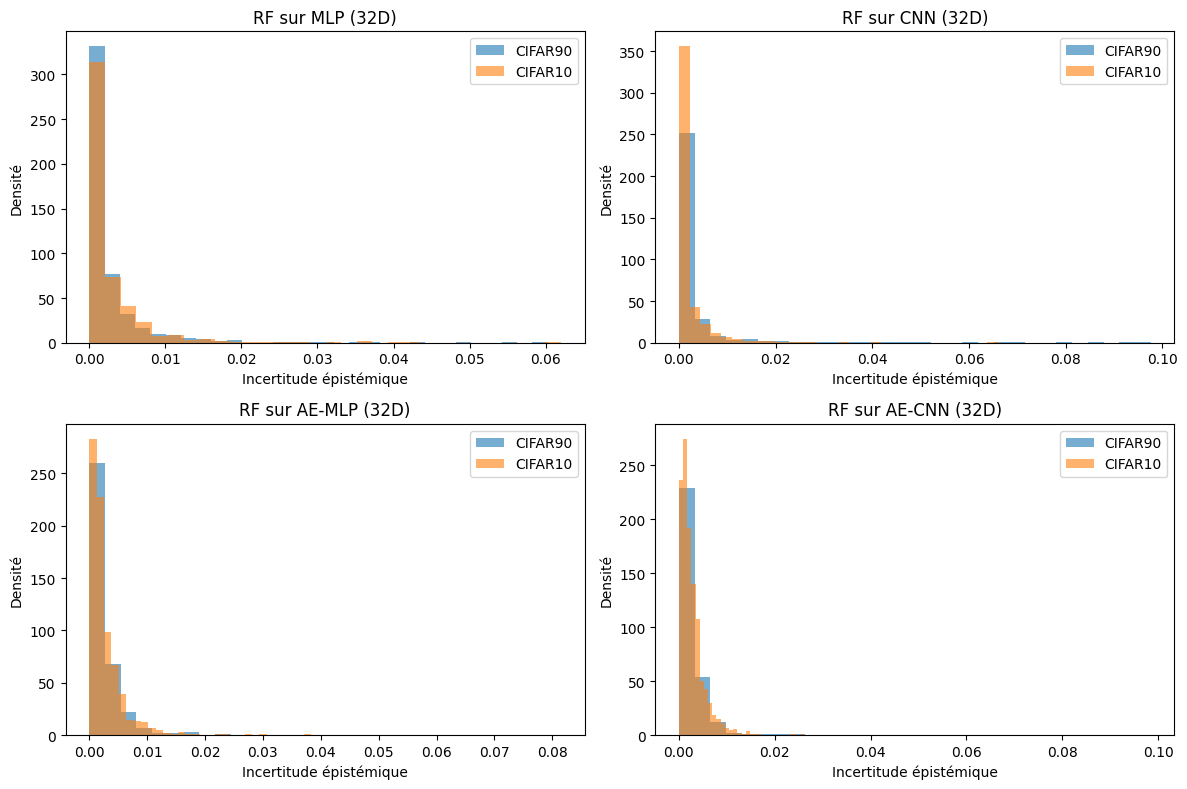

In [12]:
# Random Forest en chargeant les datasets 32D depuis le disque
import os
import torch
import numpy as np
from sklearn.ensemble import RandomForestClassifier

rep_dir = os.path.join(data_root, "representations_32")
cifar90_mlp_32 = torch.load(os.path.join(rep_dir, "cifar90_mlp_32.pt"))
cifar90_cnn_32 = torch.load(os.path.join(rep_dir, "cifar90_cnn_32.pt"))
cifar90_ae_mlp_32 = torch.load(os.path.join(rep_dir, "cifar90_ae_mlp_32.pt"))
cifar90_ae_cnn_32 = torch.load(os.path.join(rep_dir, "cifar90_ae_cnn_32.pt"))
cifar10_mlp_32_1k = torch.load(os.path.join(rep_dir, "cifar10_mlp_32_1k.pt"))
cifar10_cnn_32_1k = torch.load(os.path.join(rep_dir, "cifar10_cnn_32_1k.pt"))
cifar10_ae_mlp_32_1k = torch.load(os.path.join(rep_dir, "cifar10_ae_mlp_32_1k.pt"))
cifar10_ae_cnn_32_1k = torch.load(os.path.join(rep_dir, "cifar10_ae_cnn_32_1k.pt"))

# Données d'entraînement (CIFAR90 complet en 32D)
X_mlp_train = cifar90_mlp_32.tensors[0].numpy()
X_cnn_train = cifar90_cnn_32.tensors[0].numpy()
X_ae_mlp_train = cifar90_ae_mlp_32.tensors[0].numpy()
X_ae_cnn_train = cifar90_ae_cnn_32.tensors[0].numpy()
y_train = cifar90_mlp_32.tensors[1].numpy()

# CIFAR90 1k (échantillonnage depuis les représentations 32D sauvegardées)
rng = np.random.default_rng(1)
cifar90_idx_1k = rng.choice(len(y_train), size=1000, replace=False)
X_mlp_cifar90_1k_np = cifar90_mlp_32.tensors[0][cifar90_idx_1k].numpy()
X_cnn_cifar90_1k_np = cifar90_cnn_32.tensors[0][cifar90_idx_1k].numpy()
X_ae_mlp_cifar90_1k_np = cifar90_ae_mlp_32.tensors[0][cifar90_idx_1k].numpy()
X_ae_cnn_cifar90_1k_np = cifar90_ae_cnn_32.tensors[0][cifar90_idx_1k].numpy()

# CIFAR10 1k (déjà sauvegardé en 32D)
X_mlp_cifar10_1k_np = cifar10_mlp_32_1k.tensors[0].numpy()
X_cnn_cifar10_1k_np = cifar10_cnn_32_1k.tensors[0].numpy()
X_ae_mlp_cifar10_1k_np = cifar10_ae_mlp_32_1k.tensors[0].numpy()
X_ae_cnn_cifar10_1k_np = cifar10_ae_cnn_32_1k.tensors[0].numpy()

def randomForest(X, y, X_test, nb_estimators=200):
    model = RandomForestClassifier(n_estimators=nb_estimators, min_samples_leaf=5)

    model.fit(X, y)
    preds = np.array(model.predict_proba(X_test))

    # TREE
    unc_tree = []
    p_pred = []
    for tree in model.estimators_:
        pred_t = tree.predict_proba(X_test)
        p_pred.append(pred_t)
        unc_tree.append(-np.sum(pred_t * np.log2(pred_t + 1e-10), axis=1))

    p_pred = np.array(p_pred)
    ep = np.var(p_pred[:,:,0], axis=0)
    return ep, p_pred, preds


ep_mlp_cifar90, _, _ = randomForest(X_mlp_train, y_train, X_mlp_cifar90_1k_np)
ep_mlp_cifar10, _, _ = randomForest(X_mlp_train, y_train, X_mlp_cifar10_1k_np)

ep_cnn_cifar90, _, _ = randomForest(X_cnn_train, y_train, X_cnn_cifar90_1k_np)
ep_cnn_cifar10, _, _ = randomForest(X_cnn_train, y_train, X_cnn_cifar10_1k_np)

ep_ae_mlp_cifar90, _, _ = randomForest(X_ae_mlp_train, y_train, X_ae_mlp_cifar90_1k_np)
ep_ae_mlp_cifar10, _, _ = randomForest(X_ae_mlp_train, y_train, X_ae_mlp_cifar10_1k_np)

ep_ae_cnn_cifar90, _, _ = randomForest(X_ae_cnn_train, y_train, X_ae_cnn_cifar90_1k_np)
ep_ae_cnn_cifar10, _, _ = randomForest(X_ae_cnn_train, y_train, X_ae_cnn_cifar10_1k_np)

# Graphes de densité (CIFAR90 vs CIFAR10 1k)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], ep_mlp_cifar90, ep_mlp_cifar10, "RF sur MLP (32D)"),
    (axes[0, 1], ep_cnn_cifar90, ep_cnn_cifar10, "RF sur CNN (32D)"),
    (axes[1, 0], ep_ae_mlp_cifar90, ep_ae_mlp_cifar10, "RF sur AE-MLP (32D)"),
    (axes[1, 1], ep_ae_cnn_cifar90, ep_ae_cnn_cifar10, "RF sur AE-CNN (32D)")
]

for ax, ep_cifar90, ep_cifar10, title in plots:
    ax.hist(ep_cifar90, bins=30, density=True, alpha=0.6, label="CIFAR90")
    ax.hist(ep_cifar10, bins=30, density=True, alpha=0.6, label="CIFAR10")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()

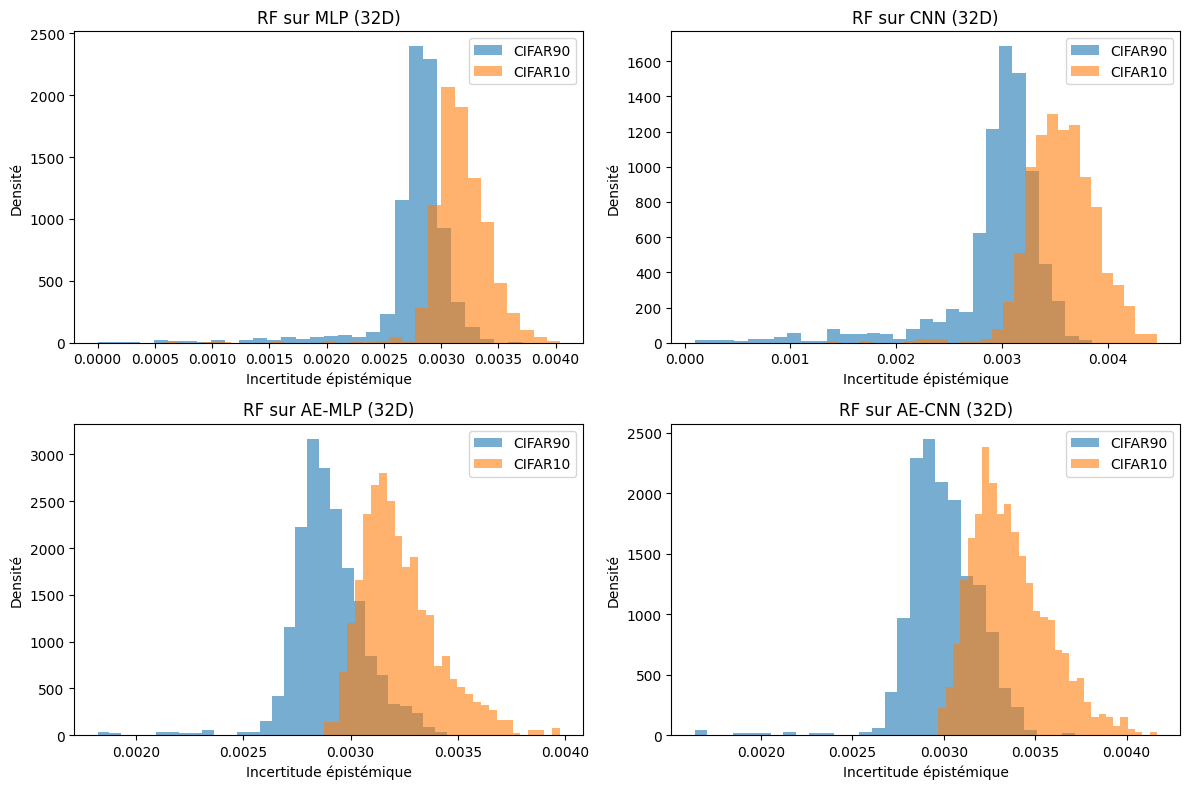

In [13]:
# Random Forest sur représentations 32D + incertitude épistémique (CIFAR90 vs CIFAR10 1k)
from sklearn.ensemble import RandomForestClassifier
from torch.utils.data import Subset

rng = np.random.default_rng(1)
cifar90_idx_1k = rng.choice(len(cifar90_test), size=1000, replace=False)
cifar10_idx_1k = rng.choice(len(cifar10_test), size=1000, replace=False)

cifar90_subset_1k = Subset(cifar90_test, cifar90_idx_1k)
cifar10_subset_1k = Subset(cifar10_test, cifar10_idx_1k)

cifar90_loader_1k = DataLoader(cifar90_subset_1k, batch_size=256, shuffle=False)
cifar10_loader_1k = DataLoader(cifar10_subset_1k, batch_size=256, shuffle=False)

# Extraire représentations 32D pour CIFAR90 1k et CIFAR10 1k
X_mlp_cifar90_1k, y_cifar90_1k = extract_mlp_features(mlp_cifar90, cifar90_loader_1k)
X_cnn_cifar90_1k, y_cnn_cifar90_1k = extract_cnn_features(cnn_cifar90, cifar90_loader_1k)
X_ae_mlp_cifar90_1k, y_ae_mlp_cifar90_1k = extract_ae_mlp_features(ae_mlp_cifar90, cifar90_loader_1k)
X_ae_cnn_cifar90_1k, y_ae_cnn_cifar90_1k = extract_ae_cnn_features(ae_cnn_cifar90, cifar90_loader_1k)

assert torch.equal(y_cifar90_1k, y_cnn_cifar90_1k)
assert torch.equal(y_cifar90_1k, y_ae_mlp_cifar90_1k)
assert torch.equal(y_cifar90_1k, y_ae_cnn_cifar90_1k)

X_mlp_cifar10_1k, y_cifar10_1k = extract_mlp_features(mlp_cifar90, cifar10_loader_1k)
X_cnn_cifar10_1k, y_cnn_cifar10_1k = extract_cnn_features(cnn_cifar90, cifar10_loader_1k)
X_ae_mlp_cifar10_1k, y_ae_mlp_cifar10_1k = extract_ae_mlp_features(ae_mlp_cifar90, cifar10_loader_1k)
X_ae_cnn_cifar10_1k, y_ae_cnn_cifar10_1k = extract_ae_cnn_features(ae_cnn_cifar90, cifar10_loader_1k)

# Conversion en numpy pour sklearn
X_mlp_train = X_mlp_full.numpy()
X_cnn_train = X_cnn_full.numpy()
X_ae_mlp_train = X_ae_mlp_full.numpy()
X_ae_cnn_train = X_ae_cnn_full.numpy()
y_train = y_full.numpy()

X_mlp_cifar90_1k_np = X_mlp_cifar90_1k.numpy()
X_cnn_cifar90_1k_np = X_cnn_cifar90_1k.numpy()
X_ae_mlp_cifar90_1k_np = X_ae_mlp_cifar90_1k.numpy()
X_ae_cnn_cifar90_1k_np = X_ae_cnn_cifar90_1k.numpy()

X_mlp_cifar10_1k_np = X_mlp_cifar10_1k.numpy()
X_cnn_cifar10_1k_np = X_cnn_cifar10_1k.numpy()
X_ae_mlp_cifar10_1k_np = X_ae_mlp_cifar10_1k.numpy()
X_ae_cnn_cifar10_1k_np = X_ae_cnn_cifar10_1k.numpy()

# Entraîner 4 Random Forest (plus d'arbres)
rf_mlp = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=0)
rf_cnn = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=0)
rf_ae_mlp = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=0)
rf_ae_cnn = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=0)

rf_mlp.fit(X_mlp_train, y_train)
rf_cnn.fit(X_cnn_train, y_train)
rf_ae_mlp.fit(X_ae_mlp_train, y_train)
rf_ae_cnn.fit(X_ae_cnn_train, y_train)

# Incertitude épistémique via variance inter‑arbres (moyenne sur classes)
def rf_epistemic(rf, X_test):
    p_pred = np.array([tree.predict_proba(X_test) for tree in rf.estimators_])
    ep = np.var(p_pred, axis=0).mean(axis=1)
    return ep

ep_mlp_cifar90 = rf_epistemic(rf_mlp, X_mlp_cifar90_1k_np)
ep_mlp_cifar10 = rf_epistemic(rf_mlp, X_mlp_cifar10_1k_np)

ep_cnn_cifar90 = rf_epistemic(rf_cnn, X_cnn_cifar90_1k_np)
ep_cnn_cifar10 = rf_epistemic(rf_cnn, X_cnn_cifar10_1k_np)

ep_ae_mlp_cifar90 = rf_epistemic(rf_ae_mlp, X_ae_mlp_cifar90_1k_np)
ep_ae_mlp_cifar10 = rf_epistemic(rf_ae_mlp, X_ae_mlp_cifar10_1k_np)

ep_ae_cnn_cifar90 = rf_epistemic(rf_ae_cnn, X_ae_cnn_cifar90_1k_np)
ep_ae_cnn_cifar10 = rf_epistemic(rf_ae_cnn, X_ae_cnn_cifar10_1k_np)

# Graphes de densité (CIFAR90 vs CIFAR10 1k)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], ep_mlp_cifar90, ep_mlp_cifar10, "RF sur MLP (32D)"),
    (axes[0, 1], ep_cnn_cifar90, ep_cnn_cifar10, "RF sur CNN (32D)"),
    (axes[1, 0], ep_ae_mlp_cifar90, ep_ae_mlp_cifar10, "RF sur AE-MLP (32D)"),
    (axes[1, 1], ep_ae_cnn_cifar90, ep_ae_cnn_cifar10, "RF sur AE-CNN (32D)")
]

for ax, ep_cifar90, ep_cifar10, title in plots:
    ax.hist(ep_cifar90, bins=30, density=True, alpha=0.6, label="CIFAR90")
    ax.hist(ep_cifar10, bins=30, density=True, alpha=0.6, label="CIFAR10")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()

### EKNN

In [14]:
# Random Forest en chargeant les datasets 32D depuis le disque
import os
import torch
import numpy as np
from deep_eknn import EKNN

rep_dir = os.path.join(data_root, "representations_32")
cifar90_mlp_32 = torch.load(os.path.join(rep_dir, "cifar90_mlp_32.pt"))
cifar90_cnn_32 = torch.load(os.path.join(rep_dir, "cifar90_cnn_32.pt"))
cifar90_ae_mlp_32 = torch.load(os.path.join(rep_dir, "cifar90_ae_mlp_32.pt"))
cifar90_ae_cnn_32 = torch.load(os.path.join(rep_dir, "cifar90_ae_cnn_32.pt"))
cifar10_mlp_32_1k = torch.load(os.path.join(rep_dir, "cifar10_mlp_32_1k.pt"))
cifar10_cnn_32_1k = torch.load(os.path.join(rep_dir, "cifar10_cnn_32_1k.pt"))
cifar10_ae_mlp_32_1k = torch.load(os.path.join(rep_dir, "cifar10_ae_mlp_32_1k.pt"))
cifar10_ae_cnn_32_1k = torch.load(os.path.join(rep_dir, "cifar10_ae_cnn_32_1k.pt"))

# Données d'entraînement (CIFAR90 complet en 32D)
X_mlp_train = cifar90_mlp_32.tensors[0].numpy()
X_cnn_train = cifar90_cnn_32.tensors[0].numpy()
X_ae_mlp_train = cifar90_ae_mlp_32.tensors[0].numpy()
X_ae_cnn_train = cifar90_ae_cnn_32.tensors[0].numpy()
y_train = cifar90_mlp_32.tensors[1].numpy()

# CIFAR90 1k (échantillonnage depuis les représentations 32D sauvegardées)
rng = np.random.default_rng(1)
cifar90_idx_1k = rng.choice(len(y_train), size=1000, replace=False)
X_mlp_cifar90_1k_np = cifar90_mlp_32.tensors[0][cifar90_idx_1k].numpy()
X_cnn_cifar90_1k_np = cifar90_cnn_32.tensors[0][cifar90_idx_1k].numpy()
X_ae_mlp_cifar90_1k_np = cifar90_ae_mlp_32.tensors[0][cifar90_idx_1k].numpy()
X_ae_cnn_cifar90_1k_np = cifar90_ae_cnn_32.tensors[0][cifar90_idx_1k].numpy()

# CIFAR10 1k (déjà sauvegardé en 32D)
X_mlp_cifar10_1k_np = cifar10_mlp_32_1k.tensors[0].numpy()
X_cnn_cifar10_1k_np = cifar10_cnn_32_1k.tensors[0].numpy()
X_ae_mlp_cifar10_1k_np = cifar10_ae_mlp_32_1k.tensors[0].numpy()
X_ae_cnn_cifar10_1k_np = cifar10_ae_cnn_32_1k.tensors[0].numpy()

def EvKNN(X, y, X_test):
    model = EKNN(2, 12)

    model.fit(X, y)
    preds = np.array(model.predict_proba(X_test))

    _, ep = model.get_uncertainties(X_test)
    
    p_pred_0 = []
    for i in range(200):
        sample = np.random.normal(preds[:,0], np.sqrt(ep))
        sample = np.clip(sample, 0, 1)
        p_pred_0.append(sample)
    p_pred_0 = np.array(p_pred_0)
    p_pred = np.array([p_pred_0, 1-p_pred_0]).transpose(1, 2, 0)

    return ep, p_pred, preds


ep_mlp_cifar90, _, _ = EvKNN(X_mlp_train, y_train, X_mlp_cifar90_1k_np)
ep_mlp_cifar10, _, _ = EvKNN(X_mlp_train, y_train, X_mlp_cifar10_1k_np)

ep_cnn_cifar90, _, _ = EvKNN(X_cnn_train, y_train, X_cnn_cifar90_1k_np)
ep_cnn_cifar10, _, _ = EvKNN(X_cnn_train, y_train, X_cnn_cifar10_1k_np)

ep_ae_mlp_cifar90, _, _ = EvKNN(X_ae_mlp_train, y_train, X_ae_mlp_cifar90_1k_np)
ep_ae_mlp_cifar10, _, _ = EvKNN(X_ae_mlp_train, y_train, X_ae_mlp_cifar10_1k_np)

ep_ae_cnn_cifar90, _, _ = EvKNN(X_ae_cnn_train, y_train, X_ae_cnn_cifar90_1k_np)
ep_ae_cnn_cifar10, _, _ = EvKNN(X_ae_cnn_train, y_train, X_ae_cnn_cifar10_1k_np)

# Graphes de densité (CIFAR90 vs CIFAR10 1k)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], ep_mlp_cifar90, ep_mlp_cifar10, "RF sur MLP (32D)"),
    (axes[0, 1], ep_cnn_cifar90, ep_cnn_cifar10, "RF sur CNN (32D)"),
    (axes[1, 0], ep_ae_mlp_cifar90, ep_ae_mlp_cifar10, "RF sur AE-MLP (32D)"),
    (axes[1, 1], ep_ae_cnn_cifar90, ep_ae_cnn_cifar10, "RF sur AE-CNN (32D)")
]

for ax, ep_cifar90, ep_cifar10, title in plots:
    ax.hist(ep_cifar90, bins=30, density=True, alpha=0.6, label="CIFAR90")
    ax.hist(ep_cifar10, bins=30, density=True, alpha=0.6, label="CIFAR10")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'lib.utils'

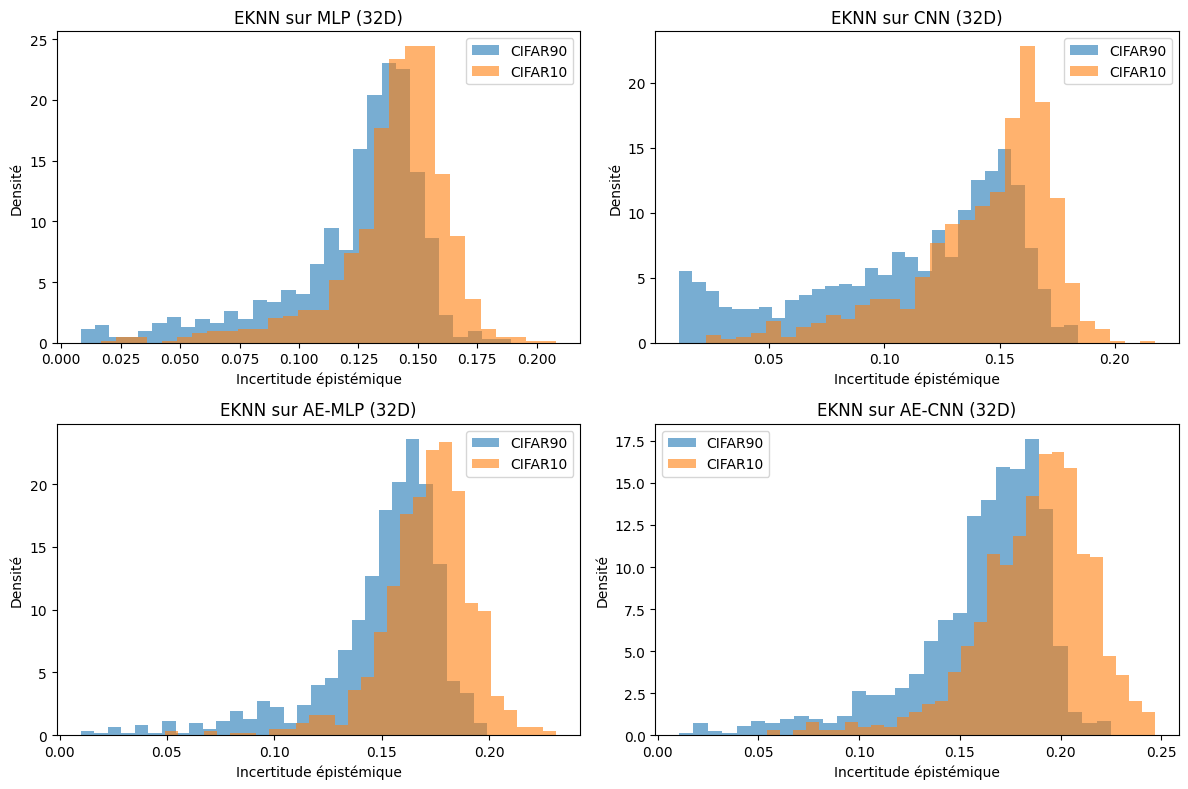

In [15]:
# EKNN sur représentations 32D + incertitude épistémique (CIFAR90 vs CIFAR10 1k)
from torch.utils.data import Subset
from sklearn.neighbors import NearestNeighbors
import math

class EKNNInline:
    def __init__(self, n_classes, n_neighbors=15, alpha=0.4, beta=0.5, random_state=0):
        self.n_classes = n_classes
        self.n_neighbors = n_neighbors
        self.alpha = alpha
        self.beta = beta
        self.random_state = random_state
        self._fitted = False

    def fit(self, X, y):
        self.X = X
        self.y = y.astype(int)
        self.nn = NearestNeighbors(n_neighbors=self.n_neighbors, metric="euclidean")
        self.nn.fit(self.X)
        self.gamma = self._compute_gamma(self.X)
        self._fitted = True
        return self

    def _compute_gamma(self, X):
        rng = np.random.default_rng(self.random_state)
        n = X.shape[0]
        m = min(10000, max(2, n // 2))
        idx = rng.choice(n, size=(m, 2), replace=False)
        distances = np.linalg.norm(X[idx[:, 0]] - X[idx[:, 1]], axis=1)
        mean_distance = np.nanmean(distances)
        return 1.0 / (mean_distance ** self.beta + 1e-12)

    def _combine_masses(self, m1, m2):
        # Dempster's rule for singletons + ignorance
        K = (1 - m1[-1]) * (1 - m2[-1]) - np.sum(m1[:-1] * m2[:-1])
        denom = 1 - K if (1 - K) > 1e-12 else 1e-12
        m = np.zeros_like(m1)
        m[:-1] = (m1[:-1] * m2[:-1] + m1[:-1] * m2[-1] + m1[-1] * m2[:-1]) / denom
        m[-1] = (m1[-1] * m2[-1]) / denom
        return m

    def _bba_for_sample(self, distances, indices):
        masses = []
        for d, idx in zip(distances, indices):
            m = np.zeros(self.n_classes + 1, dtype=np.float64)
            w = self.alpha * math.exp(-self.gamma * (d ** self.beta))
            cls = self.y[idx]
            m[cls] = w
            m[-1] = 1 - w
            masses.append(m)
        # Combine all neighbors
        m_comb = masses[0]
        for m in masses[1:]:
            m_comb = self._combine_masses(m_comb, m)
        return m_comb

    def get_uncertainties(self, X):
        if not self._fitted:
            raise RuntimeError("EKNNInline must be fitted before calling get_uncertainties.")
        distances, indices = self.nn.kneighbors(X, return_distance=True)
        bbas = np.zeros((X.shape[0], self.n_classes + 1), dtype=np.float64)
        for i in range(X.shape[0]):
            bbas[i] = self._bba_for_sample(distances[i], indices[i])
        # Epistemic: masse sur l'ignorance
        epistemic = bbas[:, -1]
        # Aleatoric: entropie de la proba pignistique
        betp = bbas[:, :-1] + bbas[:, -1][:, None] / self.n_classes
        betp = np.clip(betp, 1e-12, 1.0)
        aleatoric = -np.sum(betp * np.log2(betp), axis=1)
        return aleatoric, epistemic

rng = np.random.default_rng(2)
cifar90_idx_1k = rng.choice(len(cifar90_test), size=1000, replace=False)
cifar10_idx_1k = rng.choice(len(cifar10_test), size=1000, replace=False)

cifar90_subset_1k = Subset(cifar90_test, cifar90_idx_1k)
cifar10_subset_1k = Subset(cifar10_test, cifar10_idx_1k)

cifar90_loader_1k = DataLoader(cifar90_subset_1k, batch_size=256, shuffle=False)
cifar10_loader_1k = DataLoader(cifar10_subset_1k, batch_size=256, shuffle=False)

# Extraire représentations 32D pour CIFAR90 1k et CIFAR10 1k
X_mlp_cifar90_1k, y_cifar90_1k = extract_mlp_features(mlp_cifar90, cifar90_loader_1k)
X_cnn_cifar90_1k, y_cnn_cifar90_1k = extract_cnn_features(cnn_cifar90, cifar90_loader_1k)
X_ae_mlp_cifar90_1k, y_ae_mlp_cifar90_1k = extract_ae_mlp_features(ae_mlp_cifar90, cifar90_loader_1k)
X_ae_cnn_cifar90_1k, y_ae_cnn_cifar90_1k = extract_ae_cnn_features(ae_cnn_cifar90, cifar90_loader_1k)

X_mlp_cifar10_1k, y_cifar10_1k = extract_mlp_features(mlp_cifar90, cifar10_loader_1k)
X_cnn_cifar10_1k, y_cnn_cifar10_1k = extract_cnn_features(cnn_cifar90, cifar10_loader_1k)
X_ae_mlp_cifar10_1k, y_ae_mlp_cifar10_1k = extract_ae_mlp_features(ae_mlp_cifar90, cifar10_loader_1k)
X_ae_cnn_cifar10_1k, y_ae_cnn_cifar10_1k = extract_ae_cnn_features(ae_cnn_cifar90, cifar10_loader_1k)

# Conversion en numpy
X_mlp_train = X_mlp_full.numpy()
X_cnn_train = X_cnn_full.numpy()
X_ae_mlp_train = X_ae_mlp_full.numpy()
X_ae_cnn_train = X_ae_cnn_full.numpy()
y_train = y_full.numpy()

X_mlp_cifar90_1k_np = X_mlp_cifar90_1k.numpy()
X_cnn_cifar90_1k_np = X_cnn_cifar90_1k.numpy()
X_ae_mlp_cifar90_1k_np = X_ae_mlp_cifar90_1k.numpy()
X_ae_cnn_cifar90_1k_np = X_ae_cnn_cifar90_1k.numpy()

X_mlp_cifar10_1k_np = X_mlp_cifar10_1k.numpy()
X_cnn_cifar10_1k_np = X_cnn_cifar10_1k.numpy()
X_ae_mlp_cifar10_1k_np = X_ae_mlp_cifar10_1k.numpy()
X_ae_cnn_cifar10_1k_np = X_ae_cnn_cifar10_1k.numpy()

# Entraîner 4 EKNN
n_neighbors = 15
eknn_mlp = EKNNInline(n_classes=90, n_neighbors=n_neighbors)
eknn_cnn = EKNNInline(n_classes=90, n_neighbors=n_neighbors)
eknn_ae_mlp = EKNNInline(n_classes=90, n_neighbors=n_neighbors)
eknn_ae_cnn = EKNNInline(n_classes=90, n_neighbors=n_neighbors)

eknn_mlp.fit(X_mlp_train, y_train)
eknn_cnn.fit(X_cnn_train, y_train)
eknn_ae_mlp.fit(X_ae_mlp_train, y_train)
eknn_ae_cnn.fit(X_ae_cnn_train, y_train)

# Incertitude épistémique EKNN
_, ep_mlp_cifar90 = eknn_mlp.get_uncertainties(X_mlp_cifar90_1k_np)
_, ep_mlp_cifar10 = eknn_mlp.get_uncertainties(X_mlp_cifar10_1k_np)

_, ep_cnn_cifar90 = eknn_cnn.get_uncertainties(X_cnn_cifar90_1k_np)
_, ep_cnn_cifar10 = eknn_cnn.get_uncertainties(X_cnn_cifar10_1k_np)

_, ep_ae_mlp_cifar90 = eknn_ae_mlp.get_uncertainties(X_ae_mlp_cifar90_1k_np)
_, ep_ae_mlp_cifar10 = eknn_ae_mlp.get_uncertainties(X_ae_mlp_cifar10_1k_np)

_, ep_ae_cnn_cifar90 = eknn_ae_cnn.get_uncertainties(X_ae_cnn_cifar90_1k_np)
_, ep_ae_cnn_cifar10 = eknn_ae_cnn.get_uncertainties(X_ae_cnn_cifar10_1k_np)

# Graphes de densité (CIFAR90 vs CIFAR10 1k)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], ep_mlp_cifar90, ep_mlp_cifar10, "EKNN sur MLP (32D)"),
    (axes[0, 1], ep_cnn_cifar90, ep_cnn_cifar10, "EKNN sur CNN (32D)"),
    (axes[1, 0], ep_ae_mlp_cifar90, ep_ae_mlp_cifar10, "EKNN sur AE-MLP (32D)"),
    (axes[1, 1], ep_ae_cnn_cifar90, ep_ae_cnn_cifar10, "EKNN sur AE-CNN (32D)")
]

for ax, ep_cifar90, ep_cifar10, title in plots:
    ax.hist(ep_cifar90, bins=30, density=True, alpha=0.6, label="CIFAR90")
    ax.hist(ep_cifar10, bins=30, density=True, alpha=0.6, label="CIFAR10")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()

### Bayesian Logistic Regression

C:\Users\François\AppData\Local\Temp\ipykernel_37260\314640040.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cifar90_mlp_32 = torch.load(os.path.join(rep_dir, "cifar90

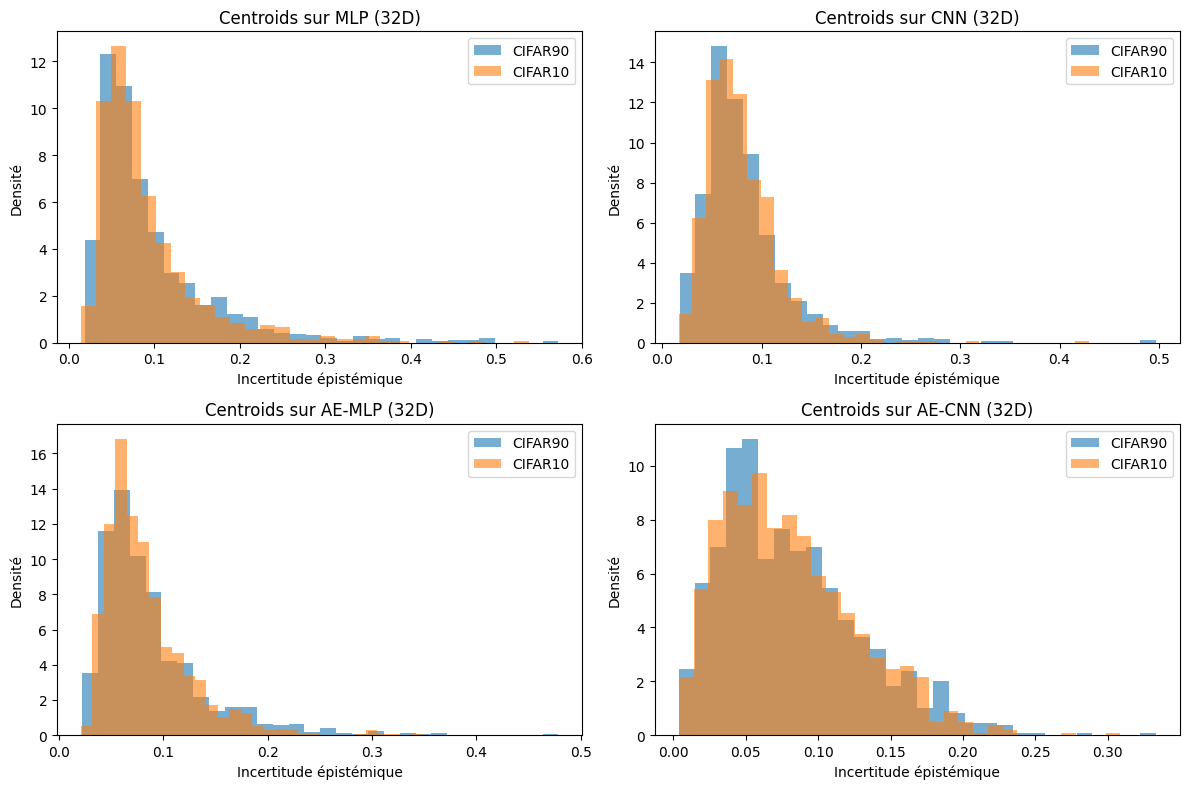

In [16]:
# Random Forest en chargeant les datasets 32D depuis le disque
import os
import torch
import numpy as np

rep_dir = os.path.join(data_root, "representations_32")
cifar90_mlp_32 = torch.load(os.path.join(rep_dir, "cifar90_mlp_32.pt"))
cifar90_cnn_32 = torch.load(os.path.join(rep_dir, "cifar90_cnn_32.pt"))
cifar90_ae_mlp_32 = torch.load(os.path.join(rep_dir, "cifar90_ae_mlp_32.pt"))
cifar90_ae_cnn_32 = torch.load(os.path.join(rep_dir, "cifar90_ae_cnn_32.pt"))
cifar10_mlp_32_1k = torch.load(os.path.join(rep_dir, "cifar10_mlp_32_1k.pt"))
cifar10_cnn_32_1k = torch.load(os.path.join(rep_dir, "cifar10_cnn_32_1k.pt"))
cifar10_ae_mlp_32_1k = torch.load(os.path.join(rep_dir, "cifar10_ae_mlp_32_1k.pt"))
cifar10_ae_cnn_32_1k = torch.load(os.path.join(rep_dir, "cifar10_ae_cnn_32_1k.pt"))

# Données d'entraînement (CIFAR90 complet en 32D)
X_mlp_train = cifar90_mlp_32.tensors[0].numpy()
X_cnn_train = cifar90_cnn_32.tensors[0].numpy()
X_ae_mlp_train = cifar90_ae_mlp_32.tensors[0].numpy()
X_ae_cnn_train = cifar90_ae_cnn_32.tensors[0].numpy()
y_train = cifar90_mlp_32.tensors[1].numpy()

# CIFAR90 1k (échantillonnage depuis les représentations 32D sauvegardées)
rng = np.random.default_rng(1)
cifar90_idx_1k = rng.choice(len(y_train), size=1000, replace=False)
X_mlp_cifar90_1k_np = cifar90_mlp_32.tensors[0][cifar90_idx_1k].numpy()
X_cnn_cifar90_1k_np = cifar90_cnn_32.tensors[0][cifar90_idx_1k].numpy()
X_ae_mlp_cifar90_1k_np = cifar90_ae_mlp_32.tensors[0][cifar90_idx_1k].numpy()
X_ae_cnn_cifar90_1k_np = cifar90_ae_cnn_32.tensors[0][cifar90_idx_1k].numpy()

# CIFAR10 1k (déjà sauvegardé en 32D)
X_mlp_cifar10_1k_np = cifar10_mlp_32_1k.tensors[0].numpy()
X_cnn_cifar10_1k_np = cifar10_cnn_32_1k.tensors[0].numpy()
X_ae_mlp_cifar10_1k_np = cifar10_ae_mlp_32_1k.tensors[0].numpy()
X_ae_cnn_cifar10_1k_np = cifar10_ae_cnn_32_1k.tensors[0].numpy()

def centroids_uncertainties(X, y, X_test, length_scale=10):
    unique_classes = np.unique(y)
    centroids = {}
    for cls in unique_classes:
        cls_positions = X[y == cls]
        centroids[cls] = np.mean(cls_positions, axis=0)

    size = len(centroids)

    uncertainties = []
    for c in centroids:
        l2 = np.linalg.norm(X_test - centroids[c], ord=2, axis=1)
        l2 = (1/size) * (l2**2)
        l2 = l2 / (2 * length_scale)
        l2 = np.exp(-l2)
        uncertainties.append(l2)
    
    preds = uncertainties / np.sum(uncertainties, axis=0)
    preds = np.array(preds).T

    ep = - np.log(np.max(uncertainties, axis=0))
    ep = ep / (ep + (10.0 * np.median(ep))) * 0.8

    p_pred_0 = []
    for i in range(200):
        sample = np.random.normal(preds[:,0], np.sqrt(ep))
        sample = np.clip(sample, 0, 1)
        p_pred_0.append(sample)
    p_pred_0 = np.array(p_pred_0)
    p_pred = np.array([p_pred_0, 1-p_pred_0]).transpose(1, 2, 0)

    return ep, p_pred, preds


ep_mlp_cifar90, _, _ = centroids_uncertainties(X_mlp_train, y_train, X_mlp_cifar90_1k_np)
ep_mlp_cifar10, _, _ = centroids_uncertainties(X_mlp_train, y_train, X_mlp_cifar10_1k_np)

ep_cnn_cifar90, _, _ = centroids_uncertainties(X_cnn_train, y_train, X_cnn_cifar90_1k_np)
ep_cnn_cifar10, _, _ = centroids_uncertainties(X_cnn_train, y_train, X_cnn_cifar10_1k_np)

ep_ae_mlp_cifar90, _, _ = centroids_uncertainties(X_ae_mlp_train, y_train, X_ae_mlp_cifar90_1k_np)
ep_ae_mlp_cifar10, _, _ = centroids_uncertainties(X_ae_mlp_train, y_train, X_ae_mlp_cifar10_1k_np)

ep_ae_cnn_cifar90, _, _ = centroids_uncertainties(X_ae_cnn_train, y_train, X_ae_cnn_cifar90_1k_np)
ep_ae_cnn_cifar10, _, _ = centroids_uncertainties(X_ae_cnn_train, y_train, X_ae_cnn_cifar10_1k_np)

# Graphes de densité (CIFAR90 vs CIFAR10 1k)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], ep_mlp_cifar90, ep_mlp_cifar10, "Centroids sur MLP (32D)"),
    (axes[0, 1], ep_cnn_cifar90, ep_cnn_cifar10, "Centroids sur CNN (32D)"),
    (axes[1, 0], ep_ae_mlp_cifar90, ep_ae_mlp_cifar10, "Centroids sur AE-MLP (32D)"),
    (axes[1, 1], ep_ae_cnn_cifar90, ep_ae_cnn_cifar10, "Centroids sur AE-CNN (32D)")
]

for ax, ep_cifar90, ep_cifar10, title in plots:
    ax.hist(ep_cifar90, bins=30, density=True, alpha=0.6, label="CIFAR90")
    ax.hist(ep_cifar10, bins=30, density=True, alpha=0.6, label="CIFAR10")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()

c:\Users\François\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\François\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.

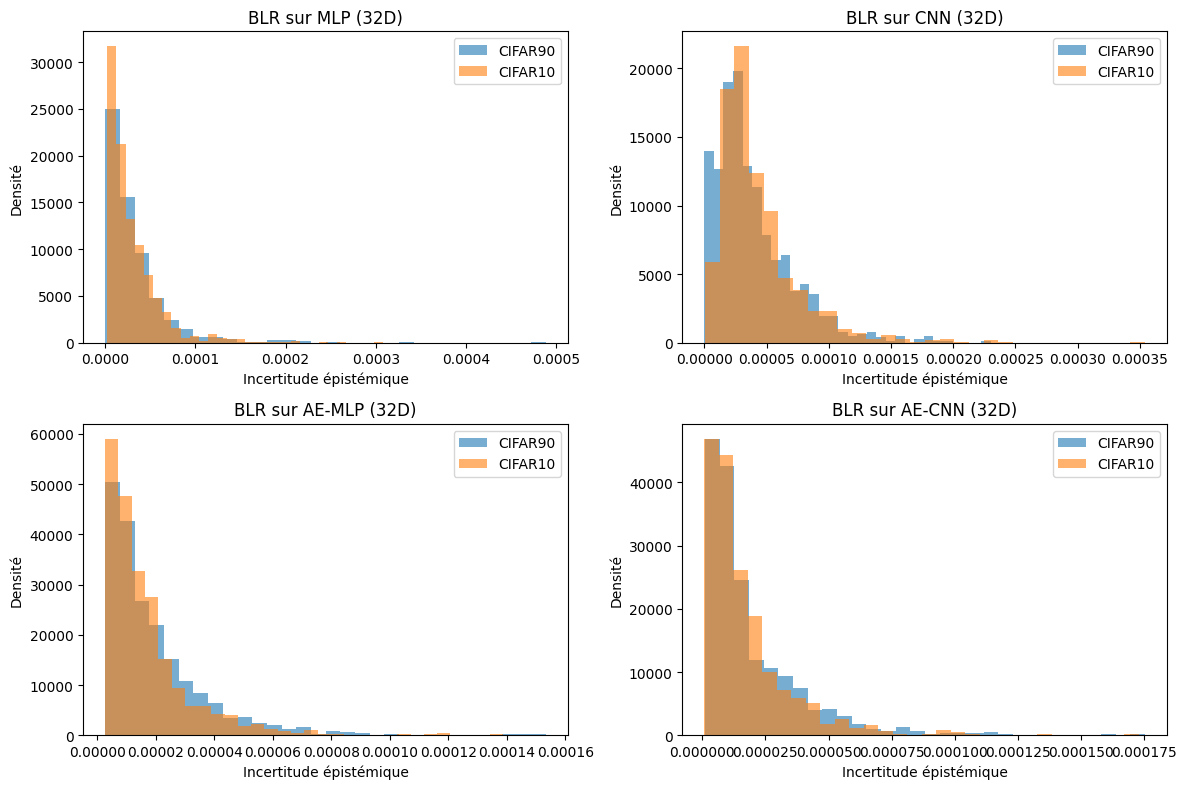

In [17]:
# Bayesian Logistic Regression (approx. Laplace) sur 32D + incertitude épistémique
from torch.utils.data import Subset
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(3)
cifar90_idx_1k = rng.choice(len(cifar90_test), size=1000, replace=False)
cifar10_idx_1k = rng.choice(len(cifar10_test), size=1000, replace=False)

cifar90_subset_1k = Subset(cifar90_test, cifar90_idx_1k)
cifar10_subset_1k = Subset(cifar10_test, cifar10_idx_1k)

cifar90_loader_1k = DataLoader(cifar90_subset_1k, batch_size=256, shuffle=False)
cifar10_loader_1k = DataLoader(cifar10_subset_1k, batch_size=256, shuffle=False)

# Extraire représentations 32D pour CIFAR90 1k et CIFAR10 1k
X_mlp_cifar90_1k, y_cifar90_1k = extract_mlp_features(mlp_cifar90, cifar90_loader_1k)
X_cnn_cifar90_1k, y_cnn_cifar90_1k = extract_cnn_features(cnn_cifar90, cifar90_loader_1k)
X_ae_mlp_cifar90_1k, y_ae_mlp_cifar90_1k = extract_ae_mlp_features(ae_mlp_cifar90, cifar90_loader_1k)
X_ae_cnn_cifar90_1k, y_ae_cnn_cifar90_1k = extract_ae_cnn_features(ae_cnn_cifar90, cifar90_loader_1k)

X_mlp_cifar10_1k, y_cifar10_1k = extract_mlp_features(mlp_cifar90, cifar10_loader_1k)
X_cnn_cifar10_1k, y_cnn_cifar10_1k = extract_cnn_features(cnn_cifar90, cifar10_loader_1k)
X_ae_mlp_cifar10_1k, y_ae_mlp_cifar10_1k = extract_ae_mlp_features(ae_mlp_cifar90, cifar10_loader_1k)
X_ae_cnn_cifar10_1k, y_ae_cnn_cifar10_1k = extract_ae_cnn_features(ae_cnn_cifar90, cifar10_loader_1k)

# Conversion en numpy
X_mlp_train = X_mlp_full.numpy()
X_cnn_train = X_cnn_full.numpy()
X_ae_mlp_train = X_ae_mlp_full.numpy()
X_ae_cnn_train = X_ae_cnn_full.numpy()
y_train = y_full.numpy()

X_mlp_cifar90_1k_np = X_mlp_cifar90_1k.numpy()
X_cnn_cifar90_1k_np = X_cnn_cifar90_1k.numpy()
X_ae_mlp_cifar90_1k_np = X_ae_mlp_cifar90_1k.numpy()
X_ae_cnn_cifar90_1k_np = X_ae_cnn_cifar90_1k.numpy()

X_mlp_cifar10_1k_np = X_mlp_cifar10_1k.numpy()
X_cnn_cifar10_1k_np = X_cnn_cifar10_1k.numpy()
X_ae_mlp_cifar10_1k_np = X_ae_mlp_cifar10_1k.numpy()
X_ae_cnn_cifar10_1k_np = X_ae_cnn_cifar10_1k.numpy()

def _sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def bayes_logreg_epistemic(X_train, y_train, X_test, n_classes=90, prior_precision=1.0, n_samples=100, seed=0):
    X_train = X_train.astype(np.float64)
    X_test = X_test.astype(np.float64)
    y_train = y_train.astype(int)

    X_aug = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
    X_test_aug = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

    weights = []
    covs = []
    for c in range(n_classes):
        y_bin = (y_train == c).astype(int)
        clf = LogisticRegression(max_iter=200, solver="lbfgs")
        clf.fit(X_train, y_bin)
        w = np.concatenate([clf.coef_.ravel(), clf.intercept_])
        logits = X_aug @ w
        p = _sigmoid(logits)
        W = p * (1 - p)
        H = (X_aug.T * W) @ X_aug + prior_precision * np.eye(X_aug.shape[1])
        cov = np.linalg.inv(H)
        weights.append(w)
        covs.append(cov)

    rng_local = np.random.default_rng(seed)
    W_samples = np.stack(
        [rng_local.multivariate_normal(weights[c], covs[c], size=n_samples) for c in range(n_classes)],
        axis=1
    )
    # logits_samples: (n_samples, n_classes, n_points)
    logits_samples = np.einsum("nd,skd->skn", X_test_aug, W_samples)
    logits_samples = np.transpose(logits_samples, (0, 2, 1))  # (n_samples, n_points, n_classes)

    logits_samples = logits_samples - logits_samples.max(axis=2, keepdims=True)
    exp_logits = np.exp(logits_samples)
    probs_samples = exp_logits / exp_logits.sum(axis=2, keepdims=True)

    ep = np.var(probs_samples, axis=0).mean(axis=1)
    return ep

# Epistémique pour CIFAR90 1k et CIFAR10 1k
blr_ep_mlp_cifar90 = bayes_logreg_epistemic(X_mlp_train, y_train, X_mlp_cifar90_1k_np, seed=0)
blr_ep_mlp_cifar10 = bayes_logreg_epistemic(X_mlp_train, y_train, X_mlp_cifar10_1k_np, seed=0)

blr_ep_cnn_cifar90 = bayes_logreg_epistemic(X_cnn_train, y_train, X_cnn_cifar90_1k_np, seed=1)
blr_ep_cnn_cifar10 = bayes_logreg_epistemic(X_cnn_train, y_train, X_cnn_cifar10_1k_np, seed=1)

blr_ep_ae_mlp_cifar90 = bayes_logreg_epistemic(X_ae_mlp_train, y_train, X_ae_mlp_cifar90_1k_np, seed=2)
blr_ep_ae_mlp_cifar10 = bayes_logreg_epistemic(X_ae_mlp_train, y_train, X_ae_mlp_cifar10_1k_np, seed=2)

blr_ep_ae_cnn_cifar90 = bayes_logreg_epistemic(X_ae_cnn_train, y_train, X_ae_cnn_cifar90_1k_np, seed=3)
blr_ep_ae_cnn_cifar10 = bayes_logreg_epistemic(X_ae_cnn_train, y_train, X_ae_cnn_cifar10_1k_np, seed=3)

# Graphes de densité (CIFAR90 vs CIFAR10 1k)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], blr_ep_mlp_cifar90, blr_ep_mlp_cifar10, "BLR sur MLP (32D)"),
    (axes[0, 1], blr_ep_cnn_cifar90, blr_ep_cnn_cifar10, "BLR sur CNN (32D)"),
    (axes[1, 0], blr_ep_ae_mlp_cifar90, blr_ep_ae_mlp_cifar10, "BLR sur AE-MLP (32D)"),
    (axes[1, 1], blr_ep_ae_cnn_cifar90, blr_ep_ae_cnn_cifar10, "BLR sur AE-CNN (32D)")
]

for ax, ep_cifar90, ep_cifar10, title in plots:
    ax.hist(ep_cifar90, bins=30, density=True, alpha=0.6, label="CIFAR90")
    ax.hist(ep_cifar10, bins=30, density=True, alpha=0.6, label="CIFAR10")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()